**PCA_KMeans_Clustering_Part1**

In [8]:
"""
PCA_KMeans_Clustering_Part1.py
K-Means clustering on PC space to identify spatial coding strategies.

Part 1: Finding optimal k and basic cluster analysis

This script:
1. Loads PCA data (PC scores for all cells)
2. Tests K-Means with k=2 to 10 clusters
3. Calculates silhouette scores to find optimal k
4. Visualizes clusters in PC space
5. Analyzes cluster composition by layer and landmark preference

JSY, 01/2026
"""

import sys
sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")

import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import seaborn as sns


# ============================================================================
# CONFIGURATION
# ============================================================================

PCA_DATA_PATH = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\JSY054_pca_data.h5"
FIGURE_DIR = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\figures_clustering"

# Use aligned profiles?
USE_ALIGNED_PROFILES = True

# Clustering parameters
N_PCS_TO_USE = 5  # Use first 5 PCs for clustering
K_RANGE = range(2, 11)  # Test k=2 to k=10
RANDOM_STATE = 42

DPI = 150


# ============================================================================
# DATA LOADING
# ============================================================================

def load_data_for_clustering(filepath, use_aligned=False):
    """
    Load PCA results and metadata for clustering analysis.
    
    Returns:
    --------
    data : dict
        Contains PC scores, layer labels, session labels, etc.
    """
    print(f"Loading data from: {filepath}")
    
    data = {}
    
    with h5py.File(filepath, 'r') as f:
        # Metadata
        data['animal_id'] = f['metadata'].attrs['animal_id']
        data['bin_centers'] = f['metadata/bin_centers_trimmed'][:]
        data['landmark_positions'] = f['metadata/landmark_positions'][:]
        
        # Cell labels
        data['session_labels'] = f['cells/session_labels'][:].astype(str)
        data['layer_labels'] = f['cells/layer_labels'][:].astype(str)
        data['preferred_landmark'] = f['cells/preferred_landmark'][:]
        data['peak_positions'] = f['cells/peak_positions'][:]
        
        # PCA results
        data['pc_scores'] = f['pca_results/pc_scores'][:]
        data['explained_variance_ratio'] = f['pca_results/explained_variance_ratio'][:]
        
        # Spatial profiles (for visualization)
        if use_aligned and 'features/spatial_profiles_aligned' in f:
            data['spatial_profiles'] = f['features/spatial_profiles_aligned'][:]
            print("  Using aligned spatial profiles")
        elif 'features/spatial_profiles_session_corrected' in f:
            data['spatial_profiles'] = f['features/spatial_profiles_session_corrected'][:]
            print("  Using session-corrected spatial profiles")
        else:
            data['spatial_profiles'] = f['features/spatial_profiles_zscore'][:]
            print("  Using z-scored spatial profiles")
    
    # Session order
    unique_sessions = np.unique(data['session_labels'])
    data['session_order'] = sorted(unique_sessions, key=lambda x: int(x.replace('Day', '')))
    
    print(f"  Animal: {data['animal_id']}")
    print(f"  Total cells: {len(data['pc_scores'])}")
    print(f"  Sessions: {data['session_order']}")
    print(f"  Layers: {np.unique(data['layer_labels'])}")
    print(f"  PC scores shape: {data['pc_scores'].shape}")
    
    return data


# ============================================================================
# K-MEANS CLUSTERING
# ============================================================================

def find_optimal_k(pc_scores, k_range, n_pcs=5):
    """
    Test different values of k and calculate metrics to find optimal.
    
    Parameters:
    -----------
    pc_scores : array (n_cells, n_pcs)
        PC scores for all cells
    k_range : range or list
        Range of k values to test
    n_pcs : int
        Number of PCs to use for clustering
    
    Returns:
    --------
    results : dict
        Contains inertia and silhouette scores for each k
    """
    print(f"\nTesting K-Means with k = {list(k_range)}")
    print(f"Using first {n_pcs} PCs")
    print(f"Total cells: {pc_scores.shape[0]}")
    
    # Use only first n_pcs
    X = pc_scores[:, :n_pcs]
    
    results = {
        'k_values': [],
        'inertia': [],
        'silhouette': [],
        'models': {}
    }
    
    print(f"\n{'k':<5} {'Inertia':<15} {'Silhouette':<15} {'Quality':<15}")
    print("-" * 50)
    
    for k in k_range:
        # Fit K-Means
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        cluster_labels = kmeans.fit_predict(X)
        
        # Calculate metrics
        inertia = kmeans.inertia_
        silhouette = silhouette_score(X, cluster_labels)
        
        # Store results
        results['k_values'].append(k)
        results['inertia'].append(inertia)
        results['silhouette'].append(silhouette)
        results['models'][k] = {
            'kmeans': kmeans,
            'labels': cluster_labels,
            'centroids': kmeans.cluster_centers_,
            'n_iter': kmeans.n_iter_
        }
        
        # Quality assessment
        if silhouette > 0.5:
            quality = "Excellent"
        elif silhouette > 0.3:
            quality = "Good"
        elif silhouette > 0.2:
            quality = "Fair"
        else:
            quality = "Poor"
        
        print(f"{k:<5} {inertia:<15.1f} {silhouette:<15.3f} {quality:<15}")
    
    # Find best k
    best_k_idx = np.argmax(results['silhouette'])
    best_k = results['k_values'][best_k_idx]
    best_silhouette = results['silhouette'][best_k_idx]
    
    print("\n" + "="*50)
    print(f"OPTIMAL k = {best_k} (silhouette = {best_silhouette:.3f})")
    print("="*50)
    
    return results


# ============================================================================
# CLUSTER ANALYSIS
# ============================================================================

def analyze_cluster_composition(cluster_labels, layer_labels, session_labels, 
                                preferred_landmark):
    """
    Analyze what each cluster contains: layers, sessions, landmark preferences.
    
    Parameters:
    -----------
    cluster_labels : array (n_cells,)
        Cluster assignment for each cell
    layer_labels : array (n_cells,)
        Layer label for each cell
    session_labels : array (n_cells,)
        Session label for each cell
    preferred_landmark : array (n_cells,)
        Preferred landmark for each cell
    
    Returns:
    --------
    composition : dict
        Composition statistics for each cluster
    """
    unique_clusters = np.unique(cluster_labels)
    n_clusters = len(unique_clusters)
    
    print(f"\n{'='*80}")
    print(f"CLUSTER COMPOSITION ANALYSIS")
    print(f"{'='*80}")
    print(f"Total clusters: {n_clusters}")
    print(f"Total cells: {len(cluster_labels)}")
    
    composition = {}
    
    for cluster in unique_clusters:
        mask = cluster_labels == cluster
        n_cells = np.sum(mask)
        
        print(f"\n{'─'*80}")
        print(f"CLUSTER {cluster} (n={n_cells} cells, {n_cells/len(cluster_labels)*100:.1f}%)")
        print(f"{'─'*80}")
        
        # Layer composition
        print(f"\nLayer Composition:")
        layer_comp = {}
        for layer in ['L2/3', 'L4', 'L5', 'L6']:
            layer_mask = (layer_labels == layer) & mask
            n_layer = np.sum(layer_mask)
            pct = n_layer / n_cells * 100 if n_cells > 0 else 0
            layer_comp[layer] = {'n': n_layer, 'pct': pct}
            print(f"  {layer}: {n_layer:>4} cells ({pct:>5.1f}%)")
        
        # Superficial vs Deep
        sup_mask = np.isin(layer_labels, ['L2/3', 'L4']) & mask
        deep_mask = np.isin(layer_labels, ['L5', 'L6']) & mask
        n_sup = np.sum(sup_mask)
        n_deep = np.sum(deep_mask)
        
        print(f"\n  Superficial (L2/3+L4): {n_sup:>4} cells ({n_sup/n_cells*100:>5.1f}%)")
        print(f"  Deep (L5+L6):          {n_deep:>4} cells ({n_deep/n_cells*100:>5.1f}%)")
        
        # Landmark preference
        print(f"\nLandmark Preference:")
        landmark_comp = {}
        valid_pref = (preferred_landmark >= 0) & (preferred_landmark < 4) & mask
        n_valid = np.sum(valid_pref)
        
        for lm_idx in range(4):
            lm_mask = (preferred_landmark == lm_idx) & mask
            n_lm = np.sum(lm_mask)
            pct = n_lm / n_valid * 100 if n_valid > 0 else 0
            landmark_comp[f'L{lm_idx+1}'] = {'n': n_lm, 'pct': pct}
            print(f"  L{lm_idx+1}: {n_lm:>4} cells ({pct:>5.1f}%)")
        
        # Identify cluster characteristic
        l4_pct = landmark_comp['L4']['pct']
        l1_pct = landmark_comp['L1']['pct']
        
        if l4_pct > 40:
            characteristic = "🎯 L4/Goal-Proximal Encoding"
        elif l1_pct > 40:
            characteristic = "🚦 L1/Track-Start Encoding"
        else:
            characteristic = "🌐 Multi-Landmark/Mixed Encoding"
        
        print(f"\n  Cluster Characteristic: {characteristic}")
        
        # Store results
        composition[cluster] = {
            'n_cells': n_cells,
            'pct_total': n_cells / len(cluster_labels) * 100,
            'layer_comp': layer_comp,
            'n_superficial': n_sup,
            'n_deep': n_deep,
            'pct_superficial': n_sup / n_cells * 100 if n_cells > 0 else 0,
            'pct_deep': n_deep / n_cells * 100 if n_cells > 0 else 0,
            'landmark_comp': landmark_comp,
            'characteristic': characteristic
        }
    
    # Summary comparison
    print(f"\n{'='*80}")
    print(f"CROSS-CLUSTER COMPARISON")
    print(f"{'='*80}")
    
    print(f"\n{'Cluster':<10} {'N Cells':<10} {'% Deep':<10} {'% L4 Pref':<15} {'Characteristic':<30}")
    print("─" * 80)
    for cluster in unique_clusters:
        comp = composition[cluster]
        print(f"{cluster:<10} {comp['n_cells']:<10} {comp['pct_deep']:<10.1f} "
              f"{comp['landmark_comp']['L4']['pct']:<15.1f} {comp['characteristic']:<30}")
    
    return composition


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_elbow_and_silhouette(results, save_path=None):
    """
    Plot elbow curve (inertia) and silhouette scores vs k.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    k_values = results['k_values']
    
    # Left: Elbow plot (inertia)
    ax1 = axes[0]
    ax1.plot(k_values, results['inertia'], 'o-', linewidth=2.5, 
            markersize=10, color='steelblue')
    
    # Find elbow point (largest decrease)
    inertia_diff = np.diff(results['inertia'])
    elbow_idx = np.argmax(np.abs(inertia_diff))
    elbow_k = k_values[elbow_idx + 1]
    
    ax1.axvline(elbow_k, color='red', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Elbow at k={elbow_k}')
    
    ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
    ax1.set_title('Elbow Method: Finding Optimal k', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3)
    ax1.set_xticks(k_values)
    
    # Right: Silhouette scores
    ax2 = axes[1]
    colors = ['darkgreen' if s == max(results['silhouette']) else 'steelblue' 
              for s in results['silhouette']]
    
    bars = ax2.bar(k_values, results['silhouette'], color=colors, 
                  alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Mark best k
    best_k_idx = np.argmax(results['silhouette'])
    best_k = k_values[best_k_idx]
    best_silhouette = results['silhouette'][best_k_idx]
    
    ax2.axhline(0.5, color='green', linestyle='--', linewidth=2, 
               alpha=0.5, label='Excellent (>0.5)')
    ax2.axhline(0.3, color='orange', linestyle='--', linewidth=2, 
               alpha=0.5, label='Good (>0.3)')
    
    # Add value labels on bars
    for bar, k, sil in zip(bars, k_values, results['silhouette']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{sil:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax2.set_ylabel('Silhouette Score', fontsize=12)
    ax2.set_title(f'Silhouette Analysis\nOptimal k={best_k} (score={best_silhouette:.3f})', 
                 fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3, axis='y')
    ax2.set_ylim(0, 1)
    ax2.set_xticks(k_values)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
        print(f"  Saved: {os.path.basename(save_path)}")
    
    return fig


def plot_clusters_in_pc_space(pc_scores, cluster_labels, layer_labels, 
                               explained_variance, n_pcs=5, save_path=None):
    """
    Visualize clusters in PC1-PC2 and PC1-PC3 space.
    Color by cluster, mark layer with different shapes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    unique_clusters = np.unique(cluster_labels)
    n_clusters = len(unique_clusters)
    
    # Color palette for clusters
    cluster_colors = plt.cm.Set2(np.linspace(0, 1, n_clusters))
    
    # Layer markers
    layer_markers = {'L2/3': 'o', 'L4': 's', 'L5': '^', 'L6': 'D'}
    
    # PC1 vs PC2
    ax1 = axes[0]
    for cluster in unique_clusters:
        cluster_mask = cluster_labels == cluster
        
        for layer in ['L2/3', 'L4', 'L5', 'L6']:
            mask = cluster_mask & (layer_labels == layer)
            if np.sum(mask) > 0:
                ax1.scatter(pc_scores[mask, 0], pc_scores[mask, 1],
                          c=[cluster_colors[cluster]], marker=layer_markers[layer],
                          s=50, alpha=0.6, edgecolors='white', linewidths=0.5,
                          label=f'C{cluster}-{layer}' if cluster == unique_clusters[0] else '')
    
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax1.axvline(0, color='gray', linestyle='--', alpha=0.3)
    ax1.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)', fontsize=12)
    ax1.set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)', fontsize=12)
    ax1.set_title(f'Clusters in PC1-PC2 Space (k={n_clusters})', 
                 fontsize=13, fontweight='bold')
    ax1.grid(alpha=0.3)
    
    # PC1 vs PC3
    ax2 = axes[1]
    for cluster in unique_clusters:
        cluster_mask = cluster_labels == cluster
        
        for layer in ['L2/3', 'L4', 'L5', 'L6']:
            mask = cluster_mask & (layer_labels == layer)
            if np.sum(mask) > 0:
                ax2.scatter(pc_scores[mask, 0], pc_scores[mask, 2],
                          c=[cluster_colors[cluster]], marker=layer_markers[layer],
                          s=50, alpha=0.6, edgecolors='white', linewidths=0.5)
    
    ax2.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax2.axvline(0, color='gray', linestyle='--', alpha=0.3)
    ax2.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)', fontsize=12)
    ax2.set_ylabel(f'PC3 ({explained_variance[2]*100:.1f}%)', fontsize=12)
    ax2.set_title(f'Clusters in PC1-PC3 Space (k={n_clusters})', 
                 fontsize=13, fontweight='bold')
    ax2.grid(alpha=0.3)
    
    # Create custom legend
    from matplotlib.lines import Line2D
    
    # Cluster legend
    cluster_legend = [Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor=cluster_colors[i], markersize=10,
                            label=f'Cluster {i}') 
                     for i in unique_clusters]
    
    # Layer legend
    layer_legend = [Line2D([0], [0], marker=layer_markers[layer], color='w',
                          markerfacecolor='gray', markersize=8,
                          label=layer)
                   for layer in ['L2/3', 'L4', 'L5', 'L6']]
    
    ax1.legend(handles=cluster_legend, title='Clusters', 
              loc='upper left', fontsize=9, title_fontsize=10)
    ax2.legend(handles=layer_legend, title='Layers',
              loc='upper left', fontsize=9, title_fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
        print(f"  Saved: {os.path.basename(save_path)}")
    
    return fig


def plot_cluster_composition(composition, save_path=None):
    """
    Visualize cluster composition: layer breakdown and landmark preferences.
    """
    unique_clusters = sorted(composition.keys())
    n_clusters = len(unique_clusters)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Panel 1: Layer composition stacked bars
    ax1 = axes[0, 0]
    
    layers = ['L2/3', 'L4', 'L5', 'L6']
    layer_colors = {'L2/3': '#1E88E5', 'L4': '#FF9800', 'L5': '#4CAF50', 'L6': '#E53935'}
    
    x = np.arange(n_clusters)
    width = 0.6
    
    bottom = np.zeros(n_clusters)
    for layer in layers:
        pcts = [composition[c]['layer_comp'][layer]['pct'] for c in unique_clusters]
        ax1.bar(x, pcts, width, bottom=bottom, label=layer,
               color=layer_colors[layer], alpha=0.8, edgecolor='black')
        bottom += pcts
    
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'Cluster {c}' for c in unique_clusters])
    ax1.set_ylabel('Percentage (%)', fontsize=12)
    ax1.set_title('Layer Composition by Cluster', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11, title='Layer')
    ax1.set_ylim(0, 100)
    ax1.grid(alpha=0.3, axis='y')
    
    # Panel 2: Superficial vs Deep
    ax2 = axes[0, 1]
    
    sup_pcts = [composition[c]['pct_superficial'] for c in unique_clusters]
    deep_pcts = [composition[c]['pct_deep'] for c in unique_clusters]
    
    x = np.arange(n_clusters)
    width = 0.35
    
    ax2.bar(x - width/2, sup_pcts, width, label='Superficial (L2/3+L4)',
           color='#1E88E5', alpha=0.8, edgecolor='black')
    ax2.bar(x + width/2, deep_pcts, width, label='Deep (L5+L6)',
           color='#4CAF50', alpha=0.8, edgecolor='black')
    
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'Cluster {c}' for c in unique_clusters])
    ax2.set_ylabel('Percentage (%)', fontsize=12)
    ax2.set_title('Superficial vs Deep Layer Composition', 
                 fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.set_ylim(0, 100)
    ax2.grid(alpha=0.3, axis='y')
    
    # Panel 3: Landmark preference
    ax3 = axes[1, 0]
    
    landmarks = ['L1', 'L2', 'L3', 'L4']
    lm_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
    
    bottom = np.zeros(n_clusters)
    for lm_idx, lm in enumerate(landmarks):
        pcts = [composition[c]['landmark_comp'][lm]['pct'] for c in unique_clusters]
        ax3.bar(x, pcts, width, bottom=bottom, label=lm,
               color=lm_colors[lm_idx], alpha=0.8, edgecolor='black')
        bottom += pcts
    
    ax3.set_xticks(x)
    ax3.set_xticklabels([f'Cluster {c}' for c in unique_clusters])
    ax3.set_ylabel('Percentage (%)', fontsize=12)
    ax3.set_title('Landmark Preference by Cluster', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=11, title='Landmark')
    ax3.set_ylim(0, 100)
    ax3.grid(alpha=0.3, axis='y')
    
    # Panel 4: Summary characteristics
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    summary_text = "CLUSTER CHARACTERISTICS:\n\n"
    
    for cluster in unique_clusters:
        comp = composition[cluster]
        summary_text += f"Cluster {cluster} (n={comp['n_cells']}):\n"
        summary_text += f"  • {comp['pct_deep']:.1f}% Deep layers\n"
        summary_text += f"  • {comp['landmark_comp']['L4']['pct']:.1f}% L4 preference\n"
        summary_text += f"  • {comp['characteristic']}\n\n"
    
    ax4.text(0.1, 0.9, summary_text, transform=ax4.transAxes,
            fontsize=11, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.suptitle('Cluster Composition Analysis: Layer and Landmark Distribution',
                fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
        print(f"  Saved: {os.path.basename(save_path)}")
    
    return fig


# ============================================================================
# MAIN WORKFLOW
# ============================================================================

def run_kmeans_clustering(pca_data_path, figure_dir, n_pcs=5, k_range=range(2, 11),
                          use_aligned=False):
    """
    Complete K-Means clustering analysis workflow.
    """
    print("="*80)
    print("K-MEANS CLUSTERING ANALYSIS")
    print("="*80)
    
    os.makedirs(figure_dir, exist_ok=True)
    
    # Load data
    data = load_data_for_clustering(pca_data_path, use_aligned=use_aligned)
    
    # Find optimal k
    results = find_optimal_k(data['pc_scores'], k_range, n_pcs=n_pcs)
    
    # Get best model
    best_k = results['k_values'][np.argmax(results['silhouette'])]
    best_model = results['models'][best_k]
    cluster_labels = best_model['labels']
    
    print(f"\nUsing k={best_k} for detailed analysis")
    
    # Analyze cluster composition
    composition = analyze_cluster_composition(
        cluster_labels,
        data['layer_labels'],
        data['session_labels'],
        data['preferred_landmark']
    )
    
    # Generate figures
    print(f"\n{'='*80}")
    print("GENERATING FIGURES...")
    print(f"{'='*80}\n")
    
    # Figure 1: Elbow and silhouette
    plot_elbow_and_silhouette(
        results,
        save_path=os.path.join(figure_dir, 'kmeans_optimal_k.png')
    )
    
    # Figure 2: Clusters in PC space
    plot_clusters_in_pc_space(
        data['pc_scores'], cluster_labels, data['layer_labels'],
        data['explained_variance_ratio'], n_pcs=n_pcs,
        save_path=os.path.join(figure_dir, f'kmeans_clusters_k{best_k}_pc_space.png')
    )
    
    # Figure 3: Cluster composition
    plot_cluster_composition(
        composition,
        save_path=os.path.join(figure_dir, f'kmeans_clusters_k{best_k}_composition.png')
    )
    
    print(f"\n{'='*80}")
    print("K-MEANS CLUSTERING COMPLETE!")
    print(f"{'='*80}")
    print(f"\nOptimal k: {best_k}")
    print(f"Silhouette score: {results['silhouette'][np.argmax(results['silhouette'])]:.3f}")
    print(f"\nFigures saved to: {figure_dir}")
    
    plt.show()
    
    return {
        'data': data,
        'results': results,
        'best_k': best_k,
        'cluster_labels': cluster_labels,
        'composition': composition
    }

K-MEANS CLUSTERING ANALYSIS
Loading data from: D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\PCA\JSY052_pca_data.h5
  Using aligned spatial profiles
  Animal: JSY052
  Total cells: 2153
  Sessions: ['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day7']
  Layers: ['L2/3' 'L4' 'L5' 'L6']
  PC scores shape: (2153, 10)

Testing K-Means with k = [2, 3, 4, 5, 6, 7, 8, 9, 10]
Using first 5 PCs
Total cells: 2153

k     Inertia         Silhouette      Quality        
--------------------------------------------------


c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


2     50097.0         0.391           Good           
3     38820.6         0.306           Good           
4     33262.6         0.262           Fair           
5     30102.9         0.231           Fair           


c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


6     27757.2         0.240           Fair           
7     25785.7         0.234           Fair           


c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\jasmineyeo\AppData\Local\

8     24282.3         0.227           Fair           
9     22892.3         0.221           Fair           
10    21638.7         0.220           Fair           

OPTIMAL k = 2 (silhouette = 0.391)

Using k=2 for detailed analysis

CLUSTER COMPOSITION ANALYSIS
Total clusters: 2
Total cells: 2153

────────────────────────────────────────────────────────────────────────────────
CLUSTER 0 (n=1339 cells, 62.2%)
────────────────────────────────────────────────────────────────────────────────

Layer Composition:
  L2/3:  407 cells ( 30.4%)
  L4:  565 cells ( 42.2%)
  L5:  219 cells ( 16.4%)
  L6:  148 cells ( 11.1%)

  Superficial (L2/3+L4):  972 cells ( 72.6%)
  Deep (L5+L6):           367 cells ( 27.4%)

Landmark Preference:
  L1:  908 cells ( 77.3%)
  L2:  214 cells ( 18.2%)
  L3:   16 cells (  1.4%)
  L4:   37 cells (  3.1%)

  Cluster Characteristic: 🚦 L1/Track-Start Encoding

────────────────────────────────────────────────────────────────────────────────
CLUSTER 1 (n=814 cells, 37.8%)

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_56456\280820088.py:562: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_56456\280820088.py:562: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_56456\280820088.py:565: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_56456\280820088.py:565: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(save_path, dpi=DPI, bbox_inches='tight')


  Saved: kmeans_clusters_k2_composition.png

K-MEANS CLUSTERING COMPLETE!

Optimal k: 2
Silhouette score: 0.391

Figures saved to: D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\PCA\figures_clustering


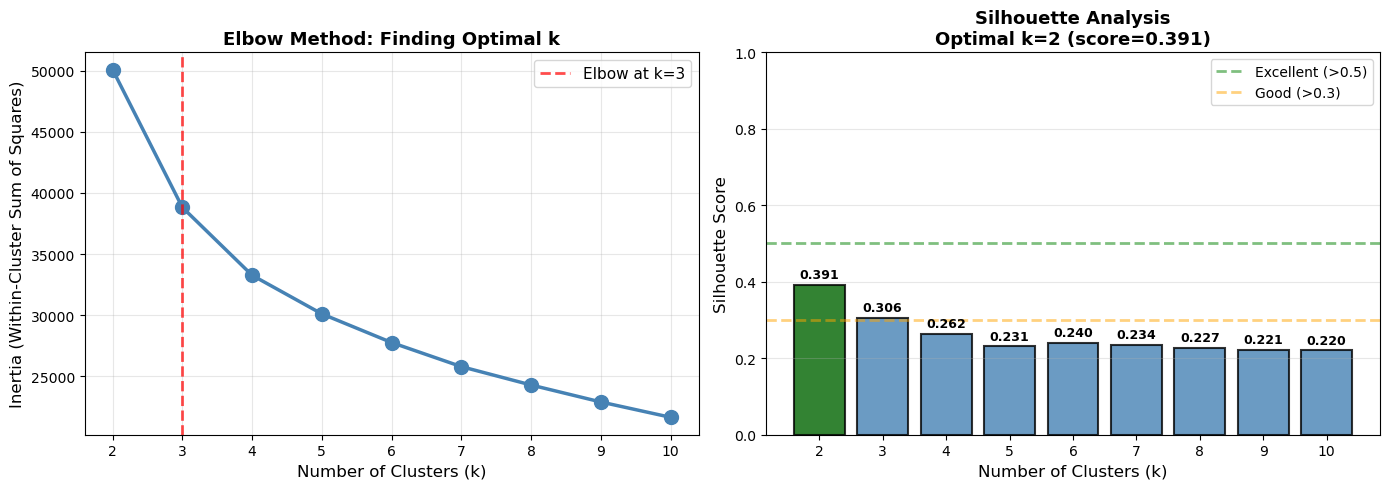

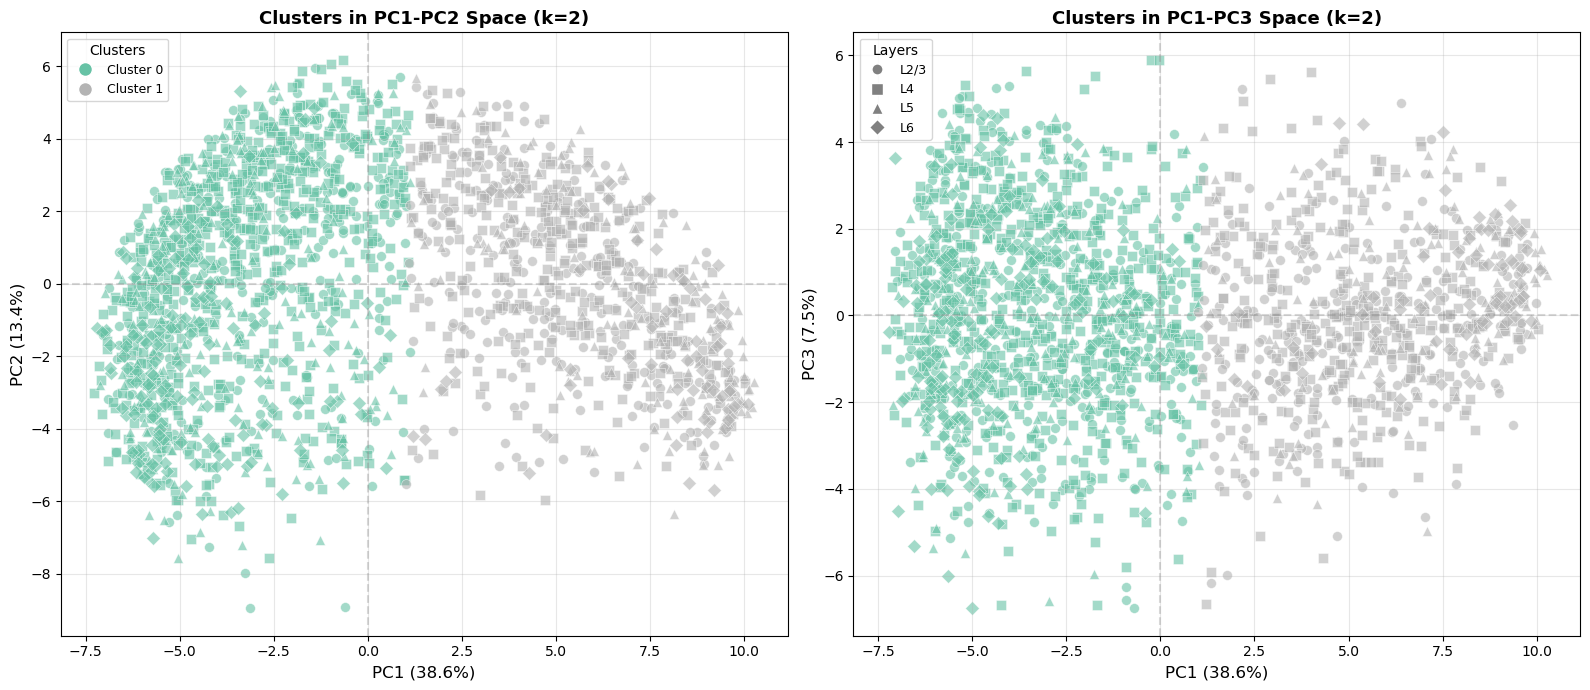

c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


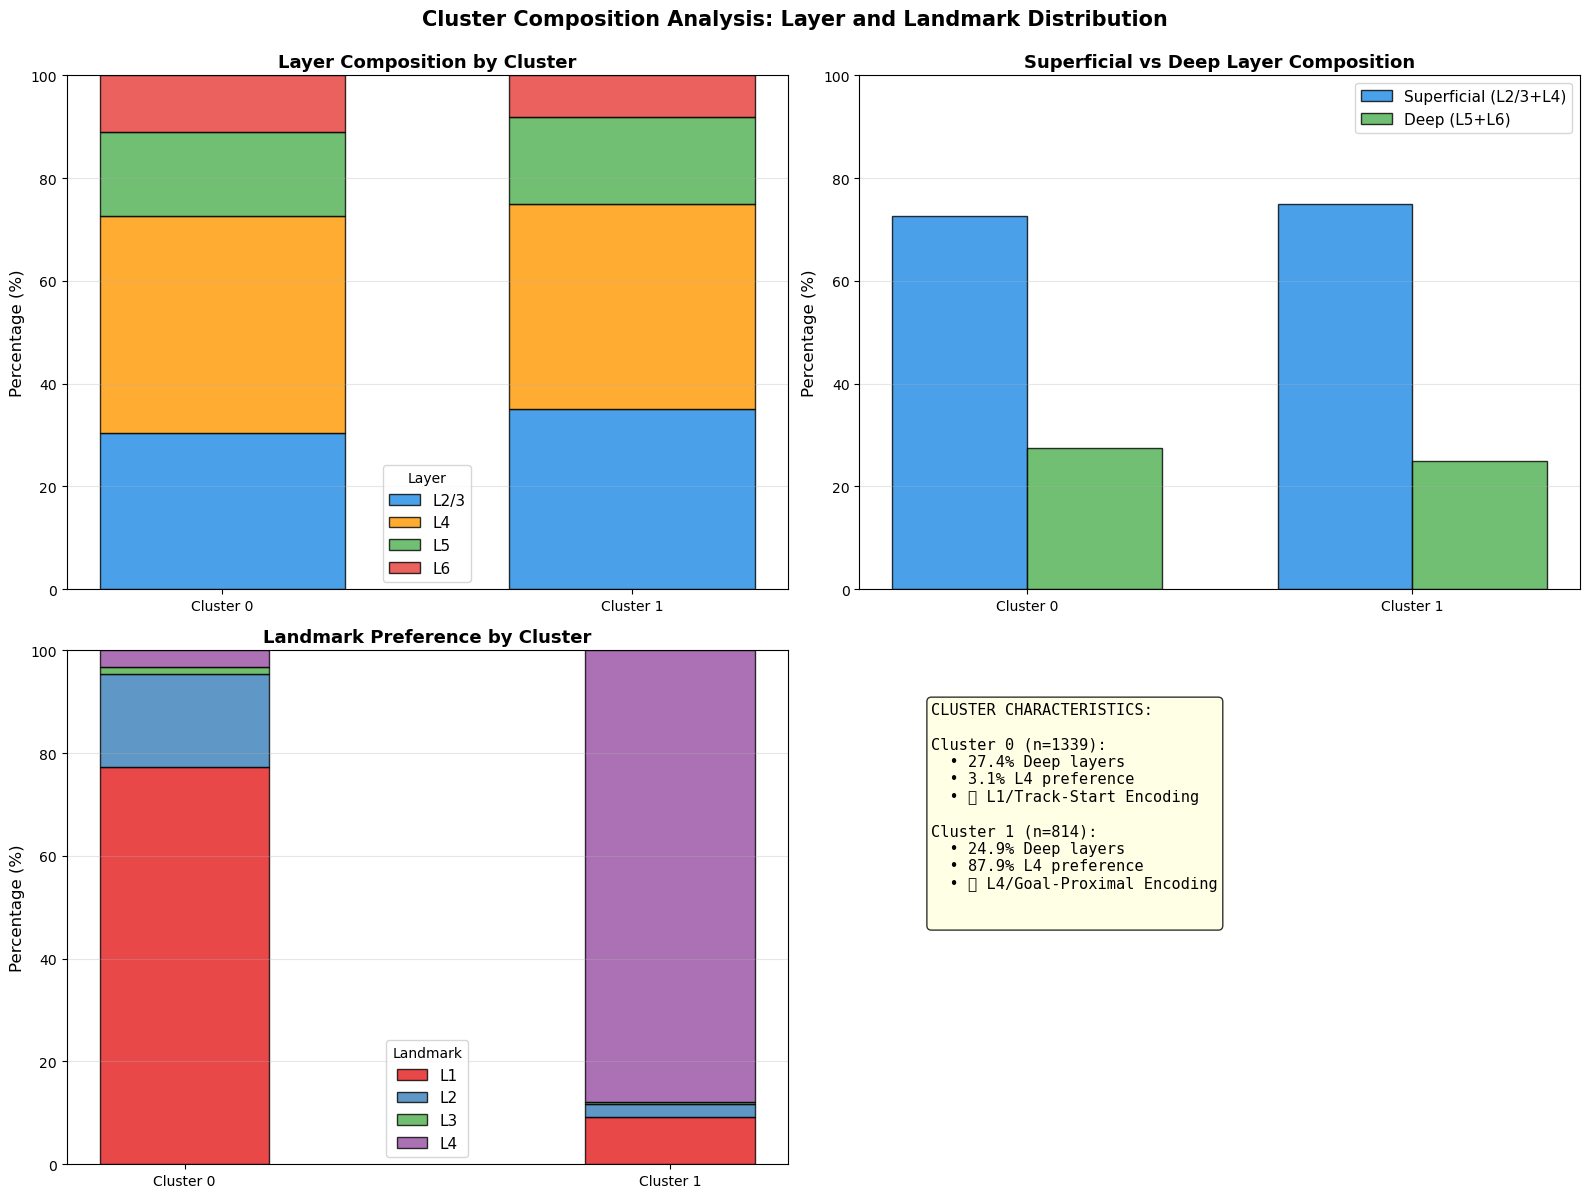

In [2]:
output = run_kmeans_clustering(
    pca_data_path=PCA_DATA_PATH,
    figure_dir=FIGURE_DIR,
    n_pcs=N_PCS_TO_USE,
    k_range=K_RANGE,
    use_aligned=USE_ALIGNED_PROFILES
)

**PCA_Cluster_Enrichment_Test**

CLUSTER ENRICHMENT TEST
Testing: Are deep layers enriched in L4-encoding cluster?
Loading data and running K-Means (k=2)...
  Total cells: 2153
  Clusters: [0 1]

CLUSTER ENRICHMENT ANALYSIS

Total cells: 2153
  Superficial (L2/3 + L4): 1583 cells (73.5%)
  Deep (L5 + L6):          570 cells (26.5%)
  Ratio: 2.78:1 (superficial:deep)

────────────────────────────────────────────────────────────────────────────────
STEP 1: Identify Cluster Characteristics
────────────────────────────────────────────────────────────────────────────────

Cluster 0:
  L1 preference: 77.3%
  L4 preference: 3.1%
  → Characteristic: L1-encoding (Track-Start)

Cluster 1:
  L1 preference: 9.1%
  L4 preference: 87.9%
  → Characteristic: L4-encoding (Goal-Proximal)

────────────────────────────────────────────────────────────────────────────────
STEP 2: Within-Layer Cluster Membership Rates
────────────────────────────────────────────────────────────────────────────────

Superficial (L2/3 + L4):
  Cluster 0 (L1-e

c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(



✓ Saved enrichment figure: D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\PCA\figures_clustering\cluster_enrichment_test.png


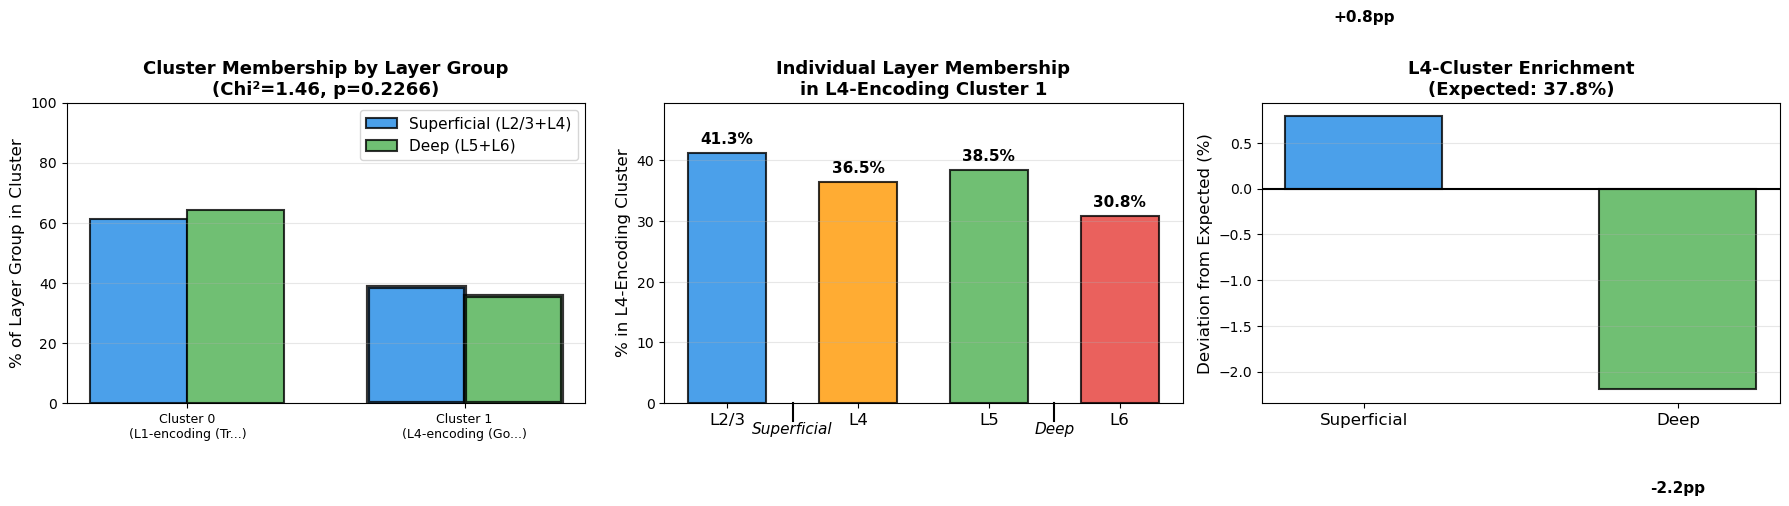

In [3]:
"""
Cluster_Enrichment_Test.py
Tests if deep layers are enriched in specific clusters compared to superficial layers.

This script answers: "Are deep layers MORE likely to be in the L4-encoding cluster
than superficial layers?"

JSY, 01/2026
"""

import sys
sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")

import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans
import seaborn as sns


# ============================================================================
# CONFIGURATION
# ============================================================================

PCA_DATA_PATH = r"D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\PCA\JSY052_pca_data.h5"
FIGURE_DIR = r"D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\PCA\figures_clustering"

N_PCS_TO_USE = 5
OPTIMAL_K = 2  # From previous analysis
RANDOM_STATE = 42


# ============================================================================
# LOAD DATA AND RUN CLUSTERING
# ============================================================================

def load_and_cluster(filepath, n_pcs=5, k=2):
    """Load data and run K-Means clustering."""
    print(f"Loading data and running K-Means (k={k})...")
    
    data = {}
    with h5py.File(filepath, 'r') as f:
        data['pc_scores'] = f['pca_results/pc_scores'][:]
        data['layer_labels'] = f['cells/layer_labels'][:].astype(str)
        data['session_labels'] = f['cells/session_labels'][:].astype(str)
        data['preferred_landmark'] = f['cells/preferred_landmark'][:]
    
    # Run K-Means
    X = data['pc_scores'][:, :n_pcs]
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    data['cluster_labels'] = kmeans.fit_predict(X)
    
    print(f"  Total cells: {len(data['cluster_labels'])}")
    print(f"  Clusters: {np.unique(data['cluster_labels'])}")
    
    return data


# ============================================================================
# ENRICHMENT ANALYSIS
# ============================================================================

def analyze_cluster_enrichment(data):
    """
    Test if deep layers are enriched in specific clusters.
    
    Key question: Of all deep layer cells, what % are in each cluster?
                  Compare to superficial layer cells.
    """
    cluster_labels = data['cluster_labels']
    layer_labels = data['layer_labels']
    preferred_landmark = data['preferred_landmark']
    
    # Define layer groups
    superficial_mask = np.isin(layer_labels, ['L2/3', 'L4'])
    deep_mask = np.isin(layer_labels, ['L5', 'L6'])
    
    n_superficial = np.sum(superficial_mask)
    n_deep = np.sum(deep_mask)
    
    print("\n" + "="*80)
    print("CLUSTER ENRICHMENT ANALYSIS")
    print("="*80)
    print(f"\nTotal cells: {len(cluster_labels)}")
    print(f"  Superficial (L2/3 + L4): {n_superficial} cells ({n_superficial/len(cluster_labels)*100:.1f}%)")
    print(f"  Deep (L5 + L6):          {n_deep} cells ({n_deep/len(cluster_labels)*100:.1f}%)")
    print(f"  Ratio: {n_superficial/n_deep:.2f}:1 (superficial:deep)")
    
    # Identify which cluster is "L4-encoding" vs "L1-encoding"
    unique_clusters = np.unique(cluster_labels)
    
    print(f"\n{'─'*80}")
    print("STEP 1: Identify Cluster Characteristics")
    print(f"{'─'*80}")
    
    cluster_characteristics = {}
    for cluster in unique_clusters:
        mask = cluster_labels == cluster
        valid_pref = (preferred_landmark >= 0) & (preferred_landmark < 4) & mask
        
        n_valid = np.sum(valid_pref)
        n_l4 = np.sum((preferred_landmark == 3) & valid_pref)
        n_l1 = np.sum((preferred_landmark == 0) & valid_pref)
        
        pct_l4 = n_l4 / n_valid * 100 if n_valid > 0 else 0
        pct_l1 = n_l1 / n_valid * 100 if n_valid > 0 else 0
        
        print(f"\nCluster {cluster}:")
        print(f"  L1 preference: {pct_l1:.1f}%")
        print(f"  L4 preference: {pct_l4:.1f}%")
        
        if pct_l4 > pct_l1:
            characteristic = "L4-encoding (Goal-Proximal)"
        else:
            characteristic = "L1-encoding (Track-Start)"
        
        print(f"  → Characteristic: {characteristic}")
        
        cluster_characteristics[cluster] = {
            'pct_l4': pct_l4,
            'pct_l1': pct_l1,
            'characteristic': characteristic
        }
    
    # =========================================================================
    # MAIN TEST: Within-layer cluster membership rates
    # =========================================================================
    
    print(f"\n{'─'*80}")
    print("STEP 2: Within-Layer Cluster Membership Rates")
    print(f"{'─'*80}")
    
    results = {}
    
    for layer_group, mask_group, label in [
        ('Superficial', superficial_mask, 'Superficial (L2/3 + L4)'),
        ('Deep', deep_mask, 'Deep (L5 + L6)')
    ]:
        print(f"\n{label}:")
        
        n_total = np.sum(mask_group)
        cluster_counts = {}
        cluster_pcts = {}
        
        for cluster in unique_clusters:
            cluster_mask = (cluster_labels == cluster) & mask_group
            n_cluster = np.sum(cluster_mask)
            pct = n_cluster / n_total * 100
            
            cluster_counts[cluster] = n_cluster
            cluster_pcts[cluster] = pct
            
            char = cluster_characteristics[cluster]['characteristic']
            print(f"  Cluster {cluster} ({char}): {n_cluster}/{n_total} = {pct:.1f}%")
        
        results[layer_group] = {
            'n_total': n_total,
            'cluster_counts': cluster_counts,
            'cluster_pcts': cluster_pcts
        }
    
    # =========================================================================
    # STATISTICAL TEST: Chi-square
    # =========================================================================
    
    print(f"\n{'─'*80}")
    print("STEP 3: Statistical Test (Chi-Square)")
    print(f"{'─'*80}")
    
    # Build contingency table
    contingency = []
    for cluster in unique_clusters:
        row = [
            results['Superficial']['cluster_counts'][cluster],
            results['Deep']['cluster_counts'][cluster]
        ]
        contingency.append(row)
    
    contingency = np.array(contingency)
    
    print(f"\nContingency Table:")
    print(f"{'':>15} {'Superficial':>15} {'Deep':>15}")
    print("─" * 50)
    for cluster in unique_clusters:
        char = cluster_characteristics[cluster]['characteristic'][:10]
        print(f"Cluster {cluster} ({char:>10}): "
              f"{contingency[cluster, 0]:>10} "
              f"{contingency[cluster, 1]:>10}")
    
    # Chi-square test
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    
    print(f"\nChi-Square Test:")
    print(f"  χ² = {chi2:.3f}")
    print(f"  df = {dof}")
    print(f"  p-value = {p_value:.6f}")
    
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "ns"
    
    print(f"  Significance: {sig}")
    
    # =========================================================================
    # INTERPRETATION
    # =========================================================================
    
    print(f"\n{'='*80}")
    print("INTERPRETATION")
    print(f"{'='*80}")
    
    # Find L4-encoding cluster
    l4_cluster = max(cluster_characteristics.items(), 
                     key=lambda x: x[1]['pct_l4'])[0]
    
    sup_l4_pct = results['Superficial']['cluster_pcts'][l4_cluster]
    deep_l4_pct = results['Deep']['cluster_pcts'][l4_cluster]
    
    diff = deep_l4_pct - sup_l4_pct
    
    print(f"\nL4-Encoding Cluster (Cluster {l4_cluster}):")
    print(f"  Superficial layers: {sup_l4_pct:.1f}% of cells in this cluster")
    print(f"  Deep layers:        {deep_l4_pct:.1f}% of cells in this cluster")
    print(f"  Difference:         {diff:+.1f} percentage points")
    
    print(f"\n{'─'*80}")
    
    if p_value < 0.05:
        if deep_l4_pct > sup_l4_pct:
            print("✓ RESULT: Deep layers are SIGNIFICANTLY MORE likely to be in")
            print("           the L4-encoding cluster than superficial layers")
            print(f"           (p = {p_value:.6f} {sig})")
            print("\n→ HYPOTHESIS SUPPORTED by clustering analysis")
        else:
            print("✗ RESULT: Deep layers are SIGNIFICANTLY LESS likely to be in")
            print("           the L4-encoding cluster than superficial layers")
            print(f"           (p = {p_value:.6f} {sig})")
            print("\n→ HYPOTHESIS NOT SUPPORTED by clustering analysis")
    else:
        print("~ RESULT: No significant difference in cluster membership")
        print("           between superficial and deep layers")
        print(f"           (p = {p_value:.6f} {sig})")
        print("\n→ Layer identity does not predict cluster membership")
        print("  (L1 vs L4 encoding strategy is orthogonal to layer)")
    
    print(f"{'='*80}\n")
    
    return results, cluster_characteristics, chi2, p_value


# ============================================================================
# DETAILED BREAKDOWN BY INDIVIDUAL LAYER
# ============================================================================

def analyze_individual_layers(data):
    """
    Break down cluster membership by individual layer (L2/3, L4, L5, L6).
    """
    cluster_labels = data['cluster_labels']
    layer_labels = data['layer_labels']
    preferred_landmark = data['preferred_landmark']
    
    print("\n" + "="*80)
    print("DETAILED BREAKDOWN: Individual Layers")
    print("="*80)
    
    layers = ['L2/3', 'L4', 'L5', 'L6']
    unique_clusters = np.unique(cluster_labels)
    
    # Identify L4-encoding cluster
    cluster_l4_pcts = {}
    for cluster in unique_clusters:
        mask = cluster_labels == cluster
        valid = (preferred_landmark >= 0) & (preferred_landmark < 4) & mask
        n_l4 = np.sum((preferred_landmark == 3) & valid)
        cluster_l4_pcts[cluster] = n_l4 / np.sum(valid) * 100 if np.sum(valid) > 0 else 0
    
    l4_cluster = max(cluster_l4_pcts, key=cluster_l4_pcts.get)
    
    print(f"\nL4-Encoding Cluster: Cluster {l4_cluster}")
    print(f"\n{'Layer':<10} {'Total':<10} {'In L4-Cluster':<15} {'% in L4-Cluster':<20}")
    print("─" * 60)
    
    layer_results = {}
    
    for layer in layers:
        layer_mask = layer_labels == layer
        n_total = np.sum(layer_mask)
        
        in_l4_cluster = np.sum((cluster_labels == l4_cluster) & layer_mask)
        pct_in_l4 = in_l4_cluster / n_total * 100 if n_total > 0 else 0
        
        print(f"{layer:<10} {n_total:<10} {in_l4_cluster:<15} {pct_in_l4:<20.1f}")
        
        layer_results[layer] = {
            'n_total': n_total,
            'in_l4_cluster': in_l4_cluster,
            'pct_in_l4': pct_in_l4
        }
    
    # Statistical test: L2/3 vs L6
    print(f"\n{'─'*80}")
    print("Statistical Comparison: L2/3 vs L6")
    print(f"{'─'*80}")
    
    l23_in = layer_results['L2/3']['in_l4_cluster']
    l23_out = layer_results['L2/3']['n_total'] - l23_in
    l6_in = layer_results['L6']['in_l4_cluster']
    l6_out = layer_results['L6']['n_total'] - l6_in
    
    contingency = np.array([
        [l23_in, l23_out],
        [l6_in, l6_out]
    ])
    
    odds_ratio, p_fisher = stats.fisher_exact(contingency)
    
    print(f"\nFisher's Exact Test (L2/3 vs L6):")
    print(f"  Odds ratio = {odds_ratio:.3f}")
    print(f"  p-value = {p_fisher:.6f}")
    
    if p_fisher < 0.05:
        if layer_results['L6']['pct_in_l4'] > layer_results['L2/3']['pct_in_l4']:
            print(f"  → L6 significantly MORE likely to be in L4-cluster")
        else:
            print(f"  → L2/3 significantly MORE likely to be in L4-cluster")
    else:
        print(f"  → No significant difference between L2/3 and L6")
    
    return layer_results


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_enrichment_results(results, cluster_characteristics, chi2, p_value, 
                            layer_results, save_path=None):
    """
    Visualize cluster enrichment by layer.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    unique_clusters = sorted(results['Superficial']['cluster_counts'].keys())
    
    # Find L4 cluster
    l4_cluster = max(cluster_characteristics.items(), 
                     key=lambda x: x[1]['pct_l4'])[0]
    
    # =========================================================================
    # Panel 1: Superficial vs Deep cluster membership
    # =========================================================================
    ax1 = axes[0]
    
    x = np.arange(len(unique_clusters))
    width = 0.35
    
    sup_pcts = [results['Superficial']['cluster_pcts'][c] for c in unique_clusters]
    deep_pcts = [results['Deep']['cluster_pcts'][c] for c in unique_clusters]
    
    bars1 = ax1.bar(x - width/2, sup_pcts, width, label='Superficial (L2/3+L4)',
                   color='#1E88E5', alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax1.bar(x + width/2, deep_pcts, width, label='Deep (L5+L6)',
                   color='#4CAF50', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Highlight L4 cluster
    if l4_cluster == 0:
        bars1[l4_cluster].set_linewidth(3)
        bars2[l4_cluster].set_linewidth(3)
    else:
        bars1[l4_cluster].set_linewidth(3)
        bars2[l4_cluster].set_linewidth(3)
    
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'Cluster {c}\n({cluster_characteristics[c]["characteristic"][:15]}...)' 
                        for c in unique_clusters], fontsize=9)
    ax1.set_ylabel('% of Layer Group in Cluster', fontsize=12)
    ax1.set_title(f'Cluster Membership by Layer Group\n(Chi²={chi2:.2f}, p={p_value:.4f})',
                 fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.set_ylim(0, 100)
    ax1.grid(alpha=0.3, axis='y')
    
    # Add significance annotation
    if p_value < 0.05:
        sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
        y_max = max(max(sup_pcts), max(deep_pcts)) + 5
        ax1.plot([l4_cluster - width/2, l4_cluster + width/2], 
                [y_max, y_max], 'k-', linewidth=2)
        ax1.text(l4_cluster, y_max + 2, sig, ha='center', fontsize=18, fontweight='bold')
    
    # =========================================================================
    # Panel 2: Individual layer breakdown
    # =========================================================================
    ax2 = axes[1]
    
    layers = ['L2/3', 'L4', 'L5', 'L6']
    layer_colors = {'L2/3': '#1E88E5', 'L4': '#FF9800', 'L5': '#4CAF50', 'L6': '#E53935'}
    
    x2 = np.arange(len(layers))
    pcts = [layer_results[layer]['pct_in_l4'] for layer in layers]
    colors_list = [layer_colors[layer] for layer in layers]
    
    bars = ax2.bar(x2, pcts, color=colors_list, alpha=0.8, 
                  edgecolor='black', linewidth=1.5, width=0.6)
    
    ax2.set_xticks(x2)
    ax2.set_xticklabels(layers, fontsize=12)
    ax2.set_ylabel('% in L4-Encoding Cluster', fontsize=12)
    ax2.set_title(f'Individual Layer Membership\nin L4-Encoding Cluster {l4_cluster}',
                 fontsize=13, fontweight='bold')
    ax2.set_ylim(0, max(pcts) * 1.2)
    ax2.grid(alpha=0.3, axis='y')
    
    # Add value labels
    for bar, pct in zip(bars, pcts):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Add bracket between superficial and deep
    ax2.plot([0.5, 0.5], [0, -3], 'k-', linewidth=1.5, clip_on=False)
    ax2.plot([2.5, 2.5], [0, -3], 'k-', linewidth=1.5, clip_on=False)
    ax2.text(0.5, -5, 'Superficial', ha='center', fontsize=11, style='italic')
    ax2.text(2.5, -5, 'Deep', ha='center', fontsize=11, style='italic')
    
    # =========================================================================
    # Panel 3: Difference from expected
    # =========================================================================
    ax3 = axes[2]
    
    # Calculate expected (if layer didn't matter)
    overall_l4_pct = np.sum([results['Superficial']['cluster_counts'][l4_cluster],
                             results['Deep']['cluster_counts'][l4_cluster]]) / \
                    (results['Superficial']['n_total'] + results['Deep']['n_total']) * 100
    
    sup_diff = results['Superficial']['cluster_pcts'][l4_cluster] - overall_l4_pct
    deep_diff = results['Deep']['cluster_pcts'][l4_cluster] - overall_l4_pct
    
    colors = ['#1E88E5', '#4CAF50']
    x3 = [0, 1]
    diffs = [sup_diff, deep_diff]
    
    bars = ax3.bar(x3, diffs, color=colors, alpha=0.8, 
                  edgecolor='black', linewidth=1.5, width=0.5)
    
    ax3.axhline(0, color='black', linestyle='-', linewidth=1.5)
    ax3.set_xticks(x3)
    ax3.set_xticklabels(['Superficial', 'Deep'], fontsize=12)
    ax3.set_ylabel('Deviation from Expected (%)', fontsize=12)
    ax3.set_title(f'L4-Cluster Enrichment\n(Expected: {overall_l4_pct:.1f}%)',
                 fontsize=13, fontweight='bold')
    ax3.grid(alpha=0.3, axis='y')
    
    # Add value labels
    for bar, diff in zip(bars, diffs):
        y_pos = diff + (1 if diff > 0 else -1)
        ax3.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{diff:+.1f}pp', ha='center', va='bottom' if diff > 0 else 'top',
                fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Saved enrichment figure: {save_path}")
    
    return fig


# ============================================================================
# MAIN
# ============================================================================

def run_enrichment_test(pca_data_path, figure_dir, n_pcs=5, k=2):
    """
    Complete enrichment test workflow.
    """
    print("="*80)
    print("CLUSTER ENRICHMENT TEST")
    print("Testing: Are deep layers enriched in L4-encoding cluster?")
    print("="*80)
    
    # Load and cluster
    data = load_and_cluster(pca_data_path, n_pcs=n_pcs, k=k)
    
    # Enrichment analysis
    results, cluster_chars, chi2, p_value = analyze_cluster_enrichment(data)
    
    # Individual layer analysis
    layer_results = analyze_individual_layers(data)
    
    # Visualization
    import os
    os.makedirs(figure_dir, exist_ok=True)
    
    fig = plot_enrichment_results(results, cluster_chars, chi2, p_value,
                                  layer_results,
                                  save_path=os.path.join(figure_dir, 
                                                        'cluster_enrichment_test.png'))
    
    plt.show()
    
    return {
        'data': data,
        'results': results,
        'cluster_characteristics': cluster_chars,
        'layer_results': layer_results,
        'chi2': chi2,
        'p_value': p_value
    }


if __name__ == "__main__":
    output = run_enrichment_test(
        pca_data_path=PCA_DATA_PATH,
        figure_dir=FIGURE_DIR,
        n_pcs=N_PCS_TO_USE,
        k=OPTIMAL_K
    )

**PCA_Clustering_Kmeans_session_specific (EARLY VS. LATE)**

Loading data from: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\JSY054_pca_data.h5
  Total cells: 2864
  Sessions: ['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
SESSION-SPECIFIC CLUSTERING ANALYSIS

EARLY SESSIONS: ['Day1', 'Day2', 'Day3']

  Sessions: ['Day1', 'Day2', 'Day3']
  Cells: 1344

L4 Cluster: 0
  Superficial: 34.8%
  Deep:        46.1%
  Difference:  +11.3pp
  p = 0.0001

LATE SESSIONS: ['Day4', 'Day5', 'Day7']

  Sessions: ['Day4', 'Day5', 'Day7']
  Cells: 1195

L4 Cluster: 1
  Superficial: 22.2%
  Deep:        34.7%
  Difference:  +12.4pp
  p = 0.0000

TRAJECTORY ANALYSIS

Deep layer advantage:
  Early: +11.3pp
  Late:  +12.4pp
  Change: +1.2pp

HYPOTHESIS TEST

1. Early enrichment: ✓
2. Late convergence: ✗
3. Difference decreased: ✗

~ HYPOTHESIS PARTIALLY SUPPORTED



c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(



✓ Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\figures_clustering\session_specific_clustering.png


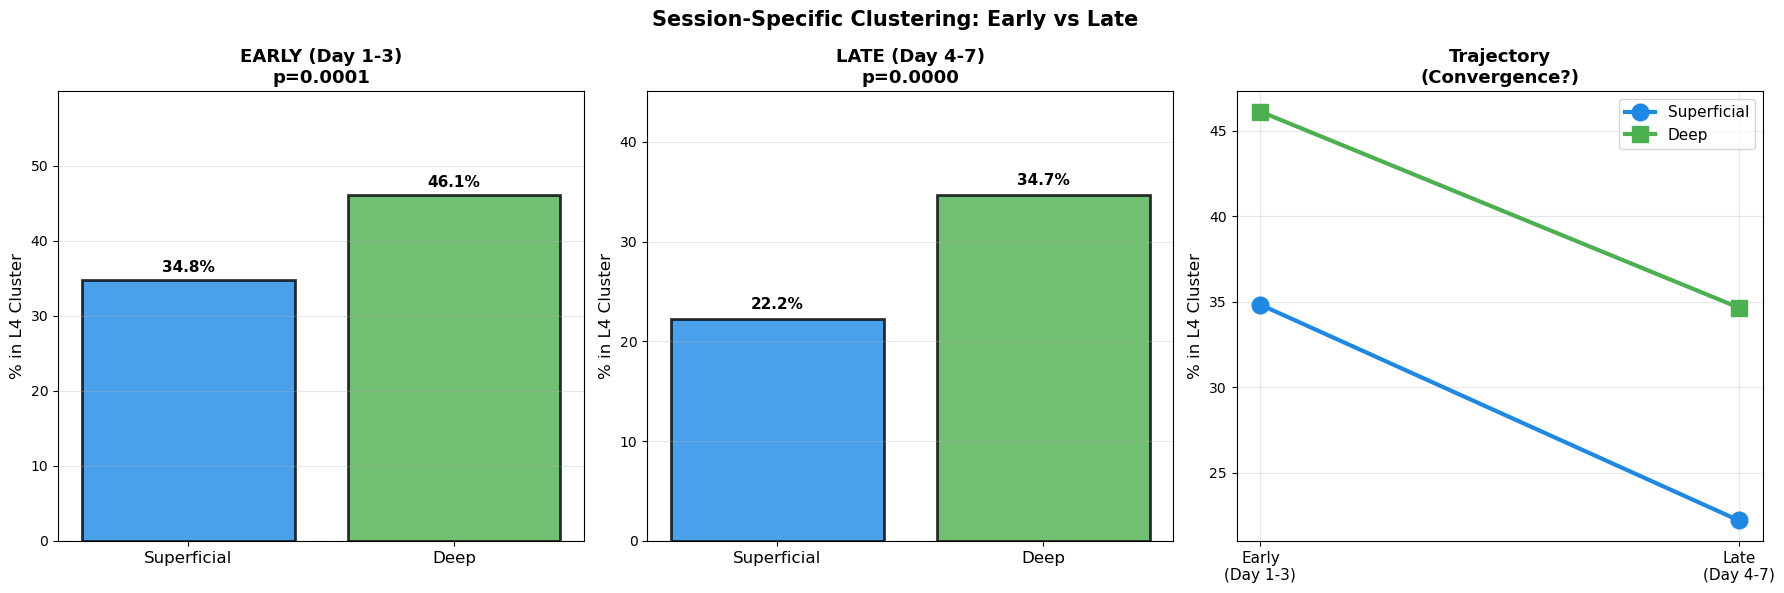

In [9]:
"""
Session_Specific_Clustering.py
Test if layer-cluster relationships change across training sessions.

KEY HYPOTHESIS TEST:
- Early sessions: Deep layers enriched in L4 cluster (hardwired bias)
- Late sessions: Deep ≈ Superficial (convergence through learning)

JSY, 01/2026
"""

import sys
sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")

import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from sklearn.cluster import KMeans


# ============================================================================
# CONFIGURATION
# ============================================================================

PCA_DATA_PATH = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\JSY054_pca_data.h5"
FIGURE_DIR = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\figures_clustering"

N_PCS_TO_USE = 5
OPTIMAL_K = 2
RANDOM_STATE = 42

# Define session groups
EARLY_SESSIONS = ['Day1', 'Day2', 'Day3']
LATE_SESSIONS = ['Day4', 'Day5', 'Day7']


# ============================================================================
# LOAD DATA
# ============================================================================

def load_data(filepath):
    """Load PCA data with session labels."""
    print(f"Loading data from: {filepath}")
    
    data = {}
    with h5py.File(filepath, 'r') as f:
        data['pc_scores'] = f['pca_results/pc_scores'][:]
        data['layer_labels'] = f['cells/layer_labels'][:].astype(str)
        data['session_labels'] = f['cells/session_labels'][:].astype(str)
        data['preferred_landmark'] = f['cells/preferred_landmark'][:]
    
    unique_sessions = np.unique(data['session_labels'])
    data['session_order'] = sorted(unique_sessions, key=lambda x: int(x.replace('Day', '')))
    
    print(f"  Total cells: {len(data['pc_scores'])}")
    print(f"  Sessions: {data['session_order']}")
    
    return data


def cluster_by_session_group(data, session_group, n_pcs=5, k=2):
    """Run clustering on specific subset of sessions."""
    session_mask = np.isin(data['session_labels'], session_group)
    
    pc_scores_subset = data['pc_scores'][session_mask, :n_pcs]
    layer_labels_subset = data['layer_labels'][session_mask]
    session_labels_subset = data['session_labels'][session_mask]
    preferred_landmark_subset = data['preferred_landmark'][session_mask]
    
    print(f"\n  Sessions: {session_group}")
    print(f"  Cells: {len(pc_scores_subset)}")
    
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans.fit_predict(pc_scores_subset)
    
    return {
        'cluster_labels': cluster_labels,
        'layer_labels': layer_labels_subset,
        'session_labels': session_labels_subset,
        'preferred_landmark': preferred_landmark_subset,
        'pc_scores': pc_scores_subset,
        'n_cells': len(cluster_labels),
        'session_group': session_group
    }


def analyze_enrichment(results):
    """Analyze cluster enrichment for a session group."""
    cluster_labels = results['cluster_labels']
    layer_labels = results['layer_labels']
    preferred_landmark = results['preferred_landmark']
    
    unique_clusters = np.unique(cluster_labels)
    
    # Identify L4-encoding cluster
    cluster_l4_pcts = {}
    for cluster in unique_clusters:
        mask = cluster_labels == cluster
        valid = (preferred_landmark >= 0) & (preferred_landmark < 4) & mask
        n_valid = np.sum(valid)
        if n_valid > 0:
            n_l4 = np.sum((preferred_landmark == 3) & valid)
            cluster_l4_pcts[cluster] = n_l4 / n_valid * 100
        else:
            cluster_l4_pcts[cluster] = 0
    
    l4_cluster = max(cluster_l4_pcts, key=cluster_l4_pcts.get)
    
    # Calculate layer membership rates
    superficial_mask = np.isin(layer_labels, ['L2/3', 'L4'])
    deep_mask = np.isin(layer_labels, ['L5', 'L6'])
    
    n_superficial = np.sum(superficial_mask)
    n_deep = np.sum(deep_mask)
    
    sup_in_l4 = np.sum((cluster_labels == l4_cluster) & superficial_mask)
    sup_l4_pct = sup_in_l4 / n_superficial * 100 if n_superficial > 0 else 0
    
    deep_in_l4 = np.sum((cluster_labels == l4_cluster) & deep_mask)
    deep_l4_pct = deep_in_l4 / n_deep * 100 if n_deep > 0 else 0
    
    # Statistical test
    contingency = np.array([
        [sup_in_l4, n_superficial - sup_in_l4],
        [deep_in_l4, n_deep - deep_in_l4]
    ])
    
    chi2, p_value = stats.chi2_contingency(contingency)[:2]
    
    # Individual layers
    layer_results = {}
    for layer in ['L2/3', 'L4', 'L5', 'L6']:
        layer_mask = layer_labels == layer
        n_layer = np.sum(layer_mask)
        in_l4 = np.sum((cluster_labels == l4_cluster) & layer_mask)
        pct_l4 = in_l4 / n_layer * 100 if n_layer > 0 else 0
        
        layer_results[layer] = {
            'n_total': n_layer,
            'in_l4_cluster': in_l4,
            'pct_l4': pct_l4
        }
    
    return {
        'l4_cluster': l4_cluster,
        'cluster_l4_pcts': cluster_l4_pcts,
        'n_superficial': n_superficial,
        'n_deep': n_deep,
        'sup_l4_pct': sup_l4_pct,
        'deep_l4_pct': deep_l4_pct,
        'diff': deep_l4_pct - sup_l4_pct,
        'chi2': chi2,
        'p_value': p_value,
        'layer_results': layer_results,
        'contingency': contingency
    }


def run_session_specific_analysis(data, early_sessions, late_sessions, n_pcs=5, k=2):
    """Run complete session-specific clustering analysis."""
    print("="*80)
    print("SESSION-SPECIFIC CLUSTERING ANALYSIS")
    print("="*80)
    
    # Early sessions
    print(f"\nEARLY SESSIONS: {early_sessions}")
    early_results = cluster_by_session_group(data, early_sessions, n_pcs=n_pcs, k=k)
    early_enrichment = analyze_enrichment(early_results)
    
    print(f"\nL4 Cluster: {early_enrichment['l4_cluster']}")
    print(f"  Superficial: {early_enrichment['sup_l4_pct']:.1f}%")
    print(f"  Deep:        {early_enrichment['deep_l4_pct']:.1f}%")
    print(f"  Difference:  {early_enrichment['diff']:+.1f}pp")
    print(f"  p = {early_enrichment['p_value']:.4f}")
    
    # Late sessions
    print(f"\nLATE SESSIONS: {late_sessions}")
    late_results = cluster_by_session_group(data, late_sessions, n_pcs=n_pcs, k=k)
    late_enrichment = analyze_enrichment(late_results)
    
    print(f"\nL4 Cluster: {late_enrichment['l4_cluster']}")
    print(f"  Superficial: {late_enrichment['sup_l4_pct']:.1f}%")
    print(f"  Deep:        {late_enrichment['deep_l4_pct']:.1f}%")
    print(f"  Difference:  {late_enrichment['diff']:+.1f}pp")
    print(f"  p = {late_enrichment['p_value']:.4f}")
    
    # Trajectory
    print(f"\n{'='*80}")
    print("TRAJECTORY ANALYSIS")
    print(f"{'='*80}")
    
    diff_change = late_enrichment['diff'] - early_enrichment['diff']
    
    print(f"\nDeep layer advantage:")
    print(f"  Early: {early_enrichment['diff']:+.1f}pp")
    print(f"  Late:  {late_enrichment['diff']:+.1f}pp")
    print(f"  Change: {diff_change:+.1f}pp")
    
    # Hypothesis test
    print(f"\n{'='*80}")
    print("HYPOTHESIS TEST")
    print(f"{'='*80}")
    
    early_supported = early_enrichment['diff'] > 0 and early_enrichment['p_value'] < 0.05
    late_converged = late_enrichment['p_value'] >= 0.05
    decreased = diff_change < -2
    
    print(f"\n1. Early enrichment: {'✓' if early_supported else '✗'}")
    print(f"2. Late convergence: {'✓' if late_converged else '✗'}")
    print(f"3. Difference decreased: {'✓' if decreased else '✗'}")
    
    if early_supported and late_converged and decreased:
        print(f"\n✓✓✓ HYPOTHESIS FULLY SUPPORTED")
    elif any([early_supported, late_converged, decreased]):
        print(f"\n~ HYPOTHESIS PARTIALLY SUPPORTED")
    else:
        print(f"\n✗ HYPOTHESIS NOT SUPPORTED")
    
    print(f"{'='*80}\n")
    
    return {
        'early_results': early_results,
        'early_enrichment': early_enrichment,
        'late_results': late_results,
        'late_enrichment': late_enrichment
    }


def plot_session_comparison(early_enrich, late_enrich, save_path=None):
    """Create comparison figure."""
    fig = plt.figure(figsize=(18, 6))
    
    # Panel 1: Early
    ax1 = plt.subplot(1, 3, 1)
    x = [0, 1]
    vals = [early_enrich['sup_l4_pct'], early_enrich['deep_l4_pct']]
    ax1.bar(x, vals, color=['#1E88E5', '#4CAF50'], alpha=0.8, edgecolor='black', linewidth=2)
    ax1.set_xticks(x)
    ax1.set_xticklabels(['Superficial', 'Deep'], fontsize=12)
    ax1.set_ylabel('% in L4 Cluster', fontsize=12)
    ax1.set_title(f'EARLY (Day 1-3)\np={early_enrich["p_value"]:.4f}', fontsize=13, fontweight='bold')
    ax1.set_ylim(0, max(vals) * 1.3)
    ax1.grid(alpha=0.3, axis='y')
    for i, v in enumerate(vals):
        ax1.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
    
    # Panel 2: Late
    ax2 = plt.subplot(1, 3, 2)
    vals2 = [late_enrich['sup_l4_pct'], late_enrich['deep_l4_pct']]
    ax2.bar(x, vals2, color=['#1E88E5', '#4CAF50'], alpha=0.8, edgecolor='black', linewidth=2)
    ax2.set_xticks(x)
    ax2.set_xticklabels(['Superficial', 'Deep'], fontsize=12)
    ax2.set_ylabel('% in L4 Cluster', fontsize=12)
    ax2.set_title(f'LATE (Day 4-7)\np={late_enrich["p_value"]:.4f}', fontsize=13, fontweight='bold')
    ax2.set_ylim(0, max(vals2) * 1.3)
    ax2.grid(alpha=0.3, axis='y')
    for i, v in enumerate(vals2):
        ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
    
    # Panel 3: Trajectory
    ax3 = plt.subplot(1, 3, 3)
    sessions = [0, 1]
    sup_traj = [early_enrich['sup_l4_pct'], late_enrich['sup_l4_pct']]
    deep_traj = [early_enrich['deep_l4_pct'], late_enrich['deep_l4_pct']]
    ax3.plot(sessions, sup_traj, 'o-', linewidth=3, markersize=12, color='#1E88E5', label='Superficial')
    ax3.plot(sessions, deep_traj, 's-', linewidth=3, markersize=12, color='#4CAF50', label='Deep')
    ax3.set_xticks(sessions)
    ax3.set_xticklabels(['Early\n(Day 1-3)', 'Late\n(Day 4-7)'], fontsize=11)
    ax3.set_ylabel('% in L4 Cluster', fontsize=12)
    ax3.set_title('Trajectory\n(Convergence?)', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=11)
    ax3.grid(alpha=0.3)
    
    plt.suptitle('Session-Specific Clustering: Early vs Late', fontsize=15, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Saved: {save_path}")
    
    return fig


def main():
    """Main function."""
    data = load_data(PCA_DATA_PATH)
    
    results = run_session_specific_analysis(
        data, EARLY_SESSIONS, LATE_SESSIONS,
        n_pcs=N_PCS_TO_USE, k=OPTIMAL_K
    )
    
    os.makedirs(FIGURE_DIR, exist_ok=True)
    
    fig = plot_session_comparison(
        results['early_enrichment'],
        results['late_enrichment'],
        save_path=os.path.join(FIGURE_DIR, 'session_specific_clustering.png')
    )
    
    plt.show()
    return results


if __name__ == "__main__":
    results = main()

**PCA_Clustering_Kmeans_day_to_day**

Loading data from: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\JSY054_pca_data.h5
  Total cells: 2864
  Sessions: ['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
DAILY CLUSTERING ANALYSIS

Day1:
----------------------------------------
  Cells: 411
  Silhouette score: 0.447
  Cluster balance: {0: 78.34549878345499, 1: 21.654501216545015}
  L4 cluster: 1 (86.4% L4)
  Superficial: 15.2%
  Deep:        34.8%
  Difference:  +19.6pp
  p-value:     0.0000

Day2:
----------------------------------------
  Cells: 452
  Silhouette score: 0.436
  Cluster balance: {0: 79.20353982300885, 1: 20.79646017699115}
  L4 cluster: 1 (79.1% L4)
  Superficial: 15.7%
  Deep:        32.4%
  Difference:  +16.7pp
  p-value:     0.0001

Day3:
----------------------------------------
  Cells: 481
  Silhouette score: 0.455
  Cluster balance: {0: 85.44698544698545, 1: 14.553014553014554}
  L4 cluster: 1 (94.0% L4)
  Superficial: 7.9%
  Deep:        30.7%
  Difference:  +22.8pp
  p-value: 

c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\jasmineyeo\AppData\Local\


✓ Saved figure: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\figures_daily_clustering\daily_clustering_trajectory.png
✓ Saved diagnostic figure: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\figures_daily_clustering\daily_clustering_diagnostics.png

✓ Saved trajectory data: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\figures_daily_clustering\daily_trajectory_data.csv


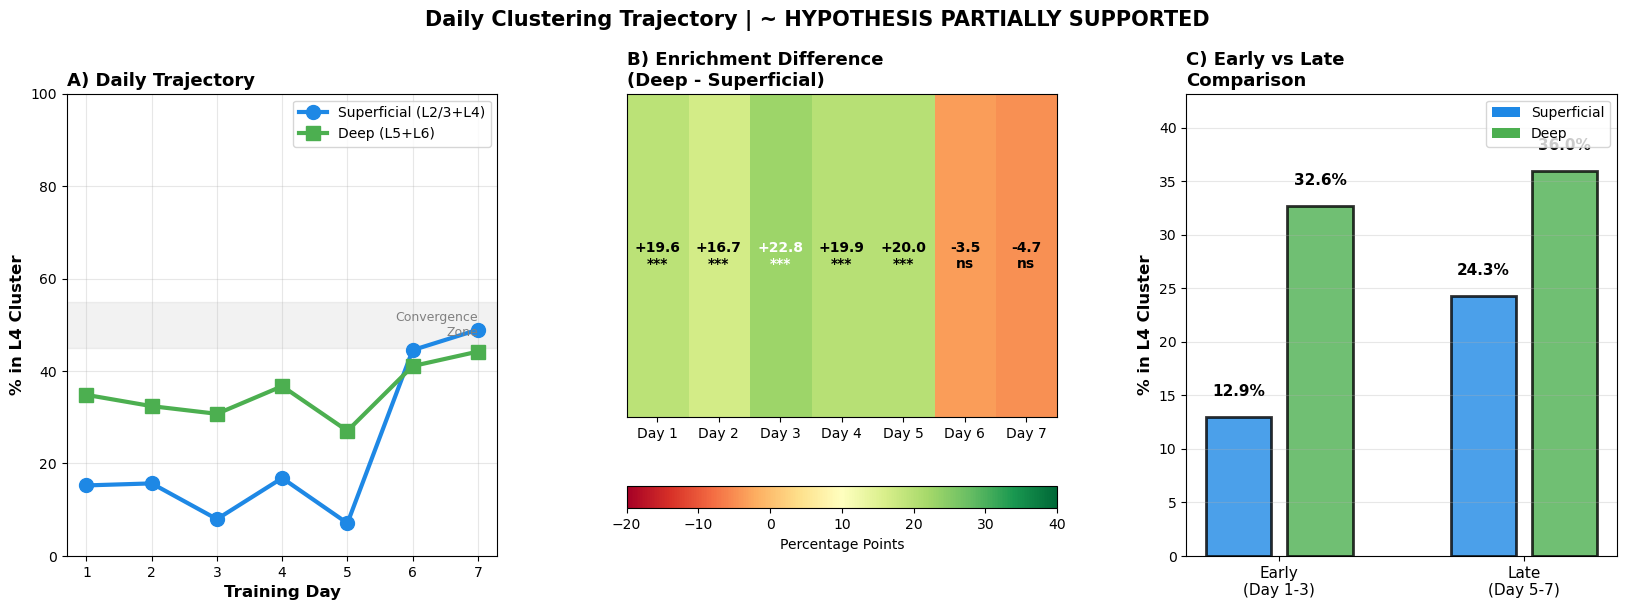

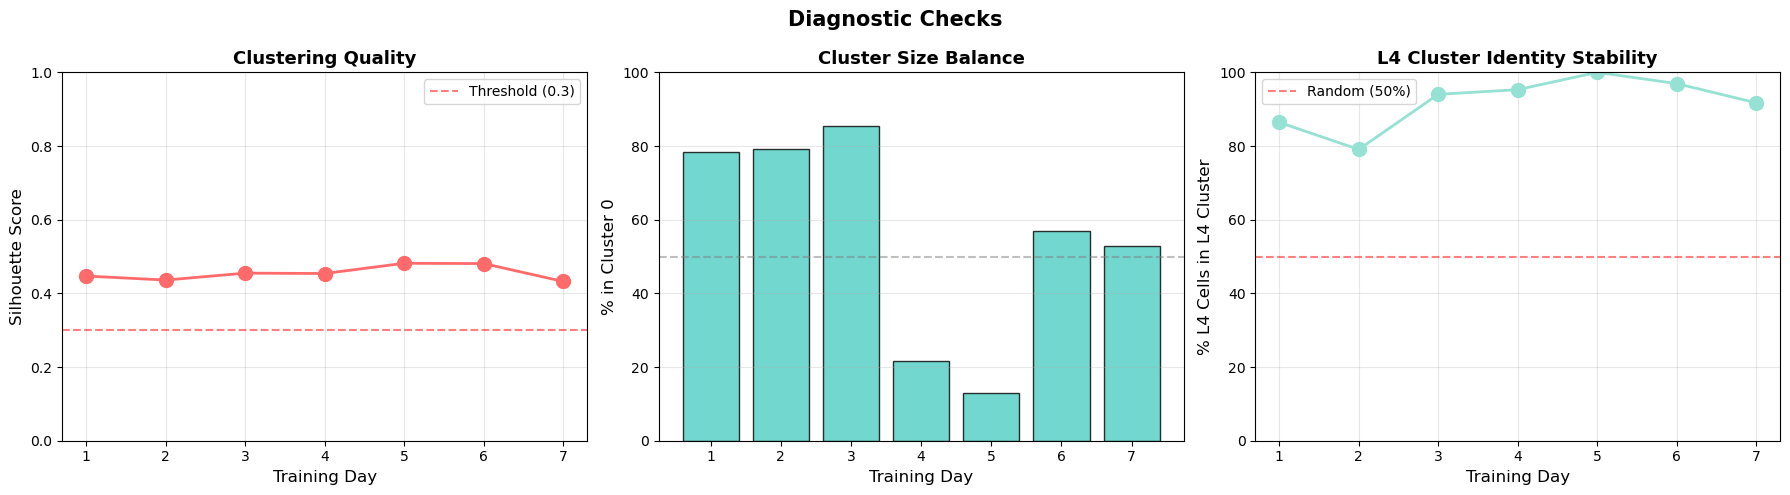

In [7]:
"""
Daily_Clustering_Analysis.py
Test if layer-cluster relationships change across individual training days.

KEY HYPOTHESIS TEST:
- Early days (1-3): Deep layers enriched in L4 cluster (hardwired bias)
- Late days (5-7): Deep ≈ Superficial (convergence through learning)
- Trajectory: Negative correlation between day and enrichment difference

JSY, 01/2026
"""

import sys
sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")

import os
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ============================================================================
# CONFIGURATION
# ============================================================================

PCA_DATA_PATH = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\JSY054_pca_data.h5"
FIGURE_DIR = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\figures_daily_clustering"

N_PCS_TO_USE = 5
OPTIMAL_K = 2
RANDOM_STATE = 42

# Define session groups for summary
EARLY_SESSIONS = ['Day1', 'Day2', 'Day3']
LATE_SESSIONS = ['Day4', 'Day5', 'Day7']


# ============================================================================
# CORE FUNCTIONS
# ============================================================================

def load_data(filepath):
    """Load PCA data with session labels."""
    print(f"Loading data from: {filepath}")
    
    data = {}
    with h5py.File(filepath, 'r') as f:
        data['pc_scores'] = f['pca_results/pc_scores'][:]
        data['layer_labels'] = f['cells/layer_labels'][:].astype(str)
        data['session_labels'] = f['cells/session_labels'][:].astype(str)
        data['preferred_landmark'] = f['cells/preferred_landmark'][:]
    
    unique_sessions = np.unique(data['session_labels'])
    data['session_order'] = sorted(unique_sessions, key=lambda x: int(x.replace('Day', '')))
    
    print(f"  Total cells: {len(data['pc_scores'])}")
    print(f"  Sessions: {data['session_order']}")
    
    return data


def cluster_single_day(data, day_label, n_pcs=5, k=2):
    """
    Run K-means clustering on a single day's cells.
    
    Parameters
    ----------
    data : dict
        Full dataset dictionary
    day_label : str
        e.g., 'Day1', 'Day2', etc.
    n_pcs : int
        Number of principal components to use
    k : int
        Number of clusters
        
    Returns
    -------
    dict with clustering results for this day
    """
    # Extract this day's cells
    day_mask = data['session_labels'] == day_label
    
    pc_subset = data['pc_scores'][day_mask, :n_pcs]
    layer_subset = data['layer_labels'][day_mask]
    landmark_subset = data['preferred_landmark'][day_mask]
    
    n_cells = len(pc_subset)
    
    if n_cells == 0:
        print(f"  WARNING: No cells found for {day_label}")
        return None
    
    # Run K-means
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans.fit_predict(pc_subset)
    
    # Calculate silhouette score
    if n_cells > k:
        silhouette = silhouette_score(pc_subset, cluster_labels)
    else:
        silhouette = np.nan
    
    # Check cluster balance
    unique, counts = np.unique(cluster_labels, return_counts=True)
    cluster_balance = dict(zip(unique, counts / n_cells * 100))
    
    return {
        'day': day_label,
        'cluster_labels': cluster_labels,
        'layer_labels': layer_subset,
        'preferred_landmark': landmark_subset,
        'pc_scores': pc_subset,
        'kmeans_model': kmeans,
        'n_cells': n_cells,
        'silhouette': silhouette,
        'cluster_balance': cluster_balance
    }


def identify_l4_cluster(cluster_labels, preferred_landmark):
    """
    Identify which cluster index (0 or 1) is the L4-preferring cluster.
    
    Parameters
    ----------
    cluster_labels : array
        K-means cluster assignments
    preferred_landmark : array
        Landmark preferences (0=L1, 1=L2, 2=L3, 3=L4)
        
    Returns
    -------
    l4_cluster_id : int
        The cluster with highest % L4-preferring cells
    cluster_profiles : dict
        Landmark preference breakdown for each cluster
    """
    unique_clusters = np.unique(cluster_labels)
    
    cluster_profiles = {}
    cluster_l4_pcts = {}
    
    for cluster_id in unique_clusters:
        mask = cluster_labels == cluster_id
        
        # Only consider cells with valid landmark preferences
        valid = (preferred_landmark >= 0) & (preferred_landmark < 4) & mask
        n_valid = np.sum(valid)
        
        if n_valid == 0:
            cluster_profiles[cluster_id] = [0, 0, 0, 0]
            cluster_l4_pcts[cluster_id] = 0
            continue
        
        # Count cells preferring each landmark
        landmark_counts = np.bincount(
            preferred_landmark[valid].astype(int), 
            minlength=4
        )
        landmark_pcts = landmark_counts / n_valid * 100
        
        cluster_profiles[cluster_id] = landmark_pcts.tolist()
        cluster_l4_pcts[cluster_id] = landmark_pcts[3]  # L4 is index 3
    
    # Identify L4 cluster as the one with highest L4 percentage
    l4_cluster_id = max(cluster_l4_pcts, key=cluster_l4_pcts.get)
    
    return l4_cluster_id, cluster_profiles, cluster_l4_pcts


def calculate_layer_enrichment(cluster_labels, layer_labels, l4_cluster_id):
    """
    Calculate layer enrichment in the L4-preferring cluster.
    
    Parameters
    ----------
    cluster_labels : array
        K-means assignments
    layer_labels : array
        Layer identities
    l4_cluster_id : int
        Which cluster is the L4-preferring one
        
    Returns
    -------
    dict with enrichment statistics
    """
    # Define layer groups
    superficial_mask = np.isin(layer_labels, ['L2/3', 'L4'])
    deep_mask = np.isin(layer_labels, ['L5', 'L6'])
    
    n_superficial = np.sum(superficial_mask)
    n_deep = np.sum(deep_mask)
    
    # Calculate membership rates in L4 cluster
    sup_in_l4 = np.sum((cluster_labels == l4_cluster_id) & superficial_mask)
    deep_in_l4 = np.sum((cluster_labels == l4_cluster_id) & deep_mask)
    
    sup_pct = sup_in_l4 / n_superficial * 100 if n_superficial > 0 else 0
    deep_pct = deep_in_l4 / n_deep * 100 if n_deep > 0 else 0
    
    enrichment_diff = deep_pct - sup_pct
    
    # Statistical test (chi-square)
    contingency = np.array([
        [sup_in_l4, n_superficial - sup_in_l4],
        [deep_in_l4, n_deep - deep_in_l4]
    ])
    
    if n_superficial > 0 and n_deep > 0:
        chi2, p_value = stats.chi2_contingency(contingency)[:2]
    else:
        chi2, p_value = np.nan, np.nan
    
    # Individual layer breakdown
    per_layer_breakdown = {}
    for layer in ['L2/3', 'L4', 'L5', 'L6']:
        layer_mask = layer_labels == layer
        n_layer = np.sum(layer_mask)
        in_l4_cluster = np.sum((cluster_labels == l4_cluster_id) & layer_mask)
        pct = in_l4_cluster / n_layer * 100 if n_layer > 0 else 0
        
        per_layer_breakdown[layer] = {
            'n_total': n_layer,
            'in_l4_cluster': in_l4_cluster,
            'pct': pct
        }
    
    return {
        'n_superficial': n_superficial,
        'n_deep': n_deep,
        'superficial_pct': sup_pct,
        'deep_pct': deep_pct,
        'enrichment_diff': enrichment_diff,
        'chi2': chi2,
        'p_value': p_value,
        'contingency': contingency,
        'per_layer_breakdown': per_layer_breakdown
    }


def run_day_by_day_analysis(data, session_list, n_pcs=5, k=2):
    """
    Run clustering analysis for each day independently.
    
    Parameters
    ----------
    data : dict
        Full dataset
    session_list : list
        List of session labels to analyze
    n_pcs : int
        Number of PCs to use
    k : int
        Number of clusters
        
    Returns
    -------
    dict with daily results and trajectory summary
    """
    print("="*80)
    print("DAILY CLUSTERING ANALYSIS")
    print("="*80)
    
    daily_results = []
    
    for day in session_list:
        print(f"\n{day}:")
        print("-" * 40)
        
        # Step 1: Cluster this day
        day_data = cluster_single_day(data, day, n_pcs=n_pcs, k=k)
        
        if day_data is None:
            continue
        
        print(f"  Cells: {day_data['n_cells']}")
        print(f"  Silhouette score: {day_data['silhouette']:.3f}")
        print(f"  Cluster balance: {day_data['cluster_balance']}")
        
        # Step 2: Identify L4 cluster
        l4_cluster_id, landmark_profiles, cluster_l4_pcts = identify_l4_cluster(
            day_data['cluster_labels'],
            day_data['preferred_landmark']
        )
        
        print(f"  L4 cluster: {l4_cluster_id} ({cluster_l4_pcts[l4_cluster_id]:.1f}% L4)")
        
        # Step 3: Calculate enrichment
        enrichment = calculate_layer_enrichment(
            day_data['cluster_labels'],
            day_data['layer_labels'],
            l4_cluster_id
        )
        
        print(f"  Superficial: {enrichment['superficial_pct']:.1f}%")
        print(f"  Deep:        {enrichment['deep_pct']:.1f}%")
        print(f"  Difference:  {enrichment['enrichment_diff']:+.1f}pp")
        print(f"  p-value:     {enrichment['p_value']:.4f}")
        
        # Store results
        daily_results.append({
            'day': day,
            'day_num': int(day.replace('Day', '')),
            'n_cells': day_data['n_cells'],
            'silhouette': day_data['silhouette'],
            'cluster_balance': day_data['cluster_balance'],
            'l4_cluster_id': l4_cluster_id,
            'landmark_profiles': landmark_profiles,
            'cluster_l4_pcts': cluster_l4_pcts,
            'enrichment': enrichment,
            'cluster_labels': day_data['cluster_labels'],
            'layer_labels': day_data['layer_labels']
        })
    
    # Create trajectory summary DataFrame
    trajectory_df = pd.DataFrame([
        {
            'Day': r['day'],
            'Day_Num': r['day_num'],
            'N_Cells': r['n_cells'],
            'Silhouette': r['silhouette'],
            'Superficial_Pct': r['enrichment']['superficial_pct'],
            'Deep_Pct': r['enrichment']['deep_pct'],
            'Enrichment_Diff': r['enrichment']['enrichment_diff'],
            'P_Value': r['enrichment']['p_value'],
            'Significant': r['enrichment']['p_value'] < 0.05
        }
        for r in daily_results
    ])
    
    print(f"\n{'='*80}")
    print("TRAJECTORY SUMMARY")
    print("="*80)
    print(trajectory_df.to_string(index=False))
    
    return {
        'daily_results': daily_results,
        'trajectory_df': trajectory_df
    }


def test_convergence_hypothesis(trajectory_df, early_sessions, late_sessions):
    """
    Test the specific convergence hypothesis.
    
    Criteria:
    1. Early enrichment: Day 1-3 average difference > 0 and significant
    2. Late convergence: Day 5-7 average difference ≈ 0 (non-significant)
    3. Negative trajectory: Correlation between day and enrichment diff < 0
    
    Returns
    -------
    dict with test results
    """
    print(f"\n{'='*80}")
    print("HYPOTHESIS TESTING")
    print("="*80)
    
    # Extract early and late periods
    early_mask = trajectory_df['Day'].isin(early_sessions)
    late_mask = trajectory_df['Day'].isin(late_sessions)
    
    early_diff = trajectory_df.loc[early_mask, 'Enrichment_Diff'].mean()
    early_sig = trajectory_df.loc[early_mask, 'Significant'].all()
    
    late_diff = trajectory_df.loc[late_mask, 'Enrichment_Diff'].mean()
    late_sig = trajectory_df.loc[late_mask, 'Significant'].any()
    
    # Trajectory correlation
    day_nums = trajectory_df['Day_Num'].values
    diffs = trajectory_df['Enrichment_Diff'].values
    
    if len(day_nums) > 2:
        corr, corr_p = stats.pearsonr(day_nums, diffs)
    else:
        corr, corr_p = np.nan, np.nan
    
    # Test criteria
    criterion1 = early_diff > 0 and early_sig
    criterion2 = not late_sig  # Late period shows no significant difference
    criterion3 = corr < 0 and corr_p < 0.05
    
    print(f"\n1. Early enrichment (Day 1-3):")
    print(f"   Mean difference: {early_diff:+.1f}pp")
    print(f"   All significant: {early_sig}")
    print(f"   CRITERION: {'✓ PASS' if criterion1 else '✗ FAIL'}")
    
    print(f"\n2. Late convergence (Day 5-7):")
    print(f"   Mean difference: {late_diff:+.1f}pp")
    print(f"   Any significant: {late_sig}")
    print(f"   CRITERION: {'✓ PASS' if criterion2 else '✗ FAIL'}")
    
    print(f"\n3. Negative trajectory:")
    print(f"   Correlation: r = {corr:.3f}, p = {corr_p:.4f}")
    print(f"   CRITERION: {'✓ PASS' if criterion3 else '✗ FAIL'}")
    
    # Overall verdict
    n_passed = sum([criterion1, criterion2, criterion3])
    
    print(f"\n{'='*80}")
    if n_passed == 3:
        verdict = "✓✓✓ HYPOTHESIS FULLY SUPPORTED"
    elif n_passed >= 2:
        verdict = "~ HYPOTHESIS PARTIALLY SUPPORTED"
    else:
        verdict = "✗ HYPOTHESIS NOT SUPPORTED"
    
    print(f"{verdict} ({n_passed}/3 criteria passed)")
    print("="*80)
    
    return {
        'early_diff': early_diff,
        'early_significant': early_sig,
        'late_diff': late_diff,
        'late_significant': late_sig,
        'trajectory_corr': corr,
        'trajectory_p': corr_p,
        'criterion1_pass': criterion1,
        'criterion2_pass': criterion2,
        'criterion3_pass': criterion3,
        'n_criteria_passed': n_passed,
        'verdict': verdict
    }


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_daily_trajectory(trajectory_df, hypothesis_test, save_path=None):
    """
    Create comprehensive visualization of daily clustering trajectory.
    
    Three panels:
    A) Line plot showing daily trajectory
    B) Heatmap of enrichment differences
    C) Early vs Late comparison
    """
    fig = plt.figure(figsize=(20, 6))
    gs = GridSpec(1, 3, figure=fig, wspace=0.3)
    
    # ========================================================================
    # PANEL A: Daily Trajectory
    # ========================================================================
    ax1 = fig.add_subplot(gs[0, 0])
    
    days = trajectory_df['Day_Num'].values
    sup_pcts = trajectory_df['Superficial_Pct'].values
    deep_pcts = trajectory_df['Deep_Pct'].values
    
    ax1.plot(days, sup_pcts, 'o-', linewidth=3, markersize=10, 
             color='#1E88E5', label='Superficial (L2/3+L4)', zorder=3)
    ax1.plot(days, deep_pcts, 's-', linewidth=3, markersize=10, 
             color='#4CAF50', label='Deep (L5+L6)', zorder=3)
    
    # Shade convergence zone (45-55%)
    ax1.axhspan(45, 55, alpha=0.1, color='gray', zorder=1)
    ax1.text(days.max(), 50, 'Convergence\nZone', 
             ha='right', va='center', fontsize=9, color='gray')
    
    ax1.set_xlabel('Training Day', fontsize=12, fontweight='bold')
    ax1.set_ylabel('% in L4 Cluster', fontsize=12, fontweight='bold')
    ax1.set_title('A) Daily Trajectory', fontsize=13, fontweight='bold', loc='left')
    ax1.legend(fontsize=10, frameon=True)
    ax1.grid(alpha=0.3)
    ax1.set_xticks(days)
    ax1.set_ylim(0, 100)
    
    # ========================================================================
    # PANEL B: Enrichment Heatmap
    # ========================================================================
    ax2 = fig.add_subplot(gs[0, 1])
    
    diffs = trajectory_df['Enrichment_Diff'].values.reshape(1, -1)
    p_vals = trajectory_df['P_Value'].values
    
    # Create heatmap
    im = ax2.imshow(diffs, cmap='RdYlGn', aspect='auto', 
                    vmin=-20, vmax=40, interpolation='nearest')
    
    # Annotate with values and significance
    for i, (diff, p) in enumerate(zip(diffs[0], p_vals)):
        sig_marker = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax2.text(i, 0, f'{diff:+.1f}\n{sig_marker}', 
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white' if abs(diff) > 20 else 'black')
    
    ax2.set_xticks(range(len(days)))
    ax2.set_xticklabels([f'Day {d}' for d in days], fontsize=10)
    ax2.set_yticks([])
    ax2.set_title('B) Enrichment Difference\n(Deep - Superficial)', 
                  fontsize=13, fontweight='bold', loc='left')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax2, orientation='horizontal', pad=0.15, aspect=20)
    cbar.set_label('Percentage Points', fontsize=10)
    
    # ========================================================================
    # PANEL C: Early vs Late Comparison
    # ========================================================================
    ax3 = fig.add_subplot(gs[0, 2])
    
    early_mask = trajectory_df['Day'].isin(EARLY_SESSIONS)
    late_mask = trajectory_df['Day'].isin(LATE_SESSIONS)
    
    early_sup = trajectory_df.loc[early_mask, 'Superficial_Pct'].mean()
    early_deep = trajectory_df.loc[early_mask, 'Deep_Pct'].mean()
    late_sup = trajectory_df.loc[late_mask, 'Superficial_Pct'].mean()
    late_deep = trajectory_df.loc[late_mask, 'Deep_Pct'].mean()
    
    x = np.array([0, 1, 3, 4])
    heights = [early_sup, early_deep, late_sup, late_deep]
    colors = ['#1E88E5', '#4CAF50', '#1E88E5', '#4CAF50']
    
    bars = ax3.bar(x, heights, width=0.8, color=colors, alpha=0.8, 
                   edgecolor='black', linewidth=2)
    
    # Add value labels
    for i, (xi, h) in enumerate(zip(x, heights)):
        ax3.text(xi, h + 2, f'{h:.1f}%', ha='center', fontsize=11, fontweight='bold')
    
    ax3.set_xticks([0.5, 3.5])
    ax3.set_xticklabels(['Early\n(Day 1-3)', 'Late\n(Day 5-7)'], fontsize=11)
    ax3.set_ylabel('% in L4 Cluster', fontsize=12, fontweight='bold')
    ax3.set_title('C) Early vs Late\nComparison', fontsize=13, fontweight='bold', loc='left')
    ax3.set_ylim(0, max(heights) * 1.2)
    ax3.grid(alpha=0.3, axis='y')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1E88E5', label='Superficial'),
        Patch(facecolor='#4CAF50', label='Deep')
    ]
    ax3.legend(handles=legend_elements, fontsize=10, loc='upper right')
    
    # ========================================================================
    # Overall title with hypothesis verdict
    # ========================================================================
    verdict = hypothesis_test['verdict']
    plt.suptitle(f'Daily Clustering Trajectory | {verdict}', 
                 fontsize=15, fontweight='bold', y=1.02)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Saved figure: {save_path}")
    
    return fig


def plot_diagnostic_checks(daily_results, save_path=None):
    """
    Create diagnostic plots to assess clustering quality.
    
    Shows:
    - Silhouette scores across days
    - Cluster balance (size distribution)
    - L4 cluster stability (% L4 cells in identified cluster)
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    days = [r['day_num'] for r in daily_results]
    
    # Panel 1: Silhouette scores
    silhouettes = [r['silhouette'] for r in daily_results]
    axes[0].plot(days, silhouettes, 'o-', linewidth=2, markersize=10, color='#FF6B6B')
    axes[0].axhline(0.3, linestyle='--', color='red', alpha=0.5, label='Threshold (0.3)')
    axes[0].set_xlabel('Training Day', fontsize=12)
    axes[0].set_ylabel('Silhouette Score', fontsize=12)
    axes[0].set_title('Clustering Quality', fontsize=13, fontweight='bold')
    axes[0].grid(alpha=0.3)
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    
    # Panel 2: Cluster balance
    balances = [list(r['cluster_balance'].values())[0] for r in daily_results]
    axes[1].bar(days, balances, color='#4ECDC4', alpha=0.8, edgecolor='black')
    axes[1].axhline(50, linestyle='--', color='gray', alpha=0.5)
    axes[1].set_xlabel('Training Day', fontsize=12)
    axes[1].set_ylabel('% in Cluster 0', fontsize=12)
    axes[1].set_title('Cluster Size Balance', fontsize=13, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    axes[1].set_ylim(0, 100)
    
    # Panel 3: L4 cluster stability
    l4_pcts = [r['cluster_l4_pcts'][r['l4_cluster_id']] for r in daily_results]
    axes[2].plot(days, l4_pcts, 'o-', linewidth=2, markersize=10, color='#95E1D3')
    axes[2].axhline(50, linestyle='--', color='red', alpha=0.5, label='Random (50%)')
    axes[2].set_xlabel('Training Day', fontsize=12)
    axes[2].set_ylabel('% L4 Cells in L4 Cluster', fontsize=12)
    axes[2].set_title('L4 Cluster Identity Stability', fontsize=13, fontweight='bold')
    axes[2].grid(alpha=0.3)
    axes[2].legend()
    axes[2].set_ylim(0, 100)
    
    plt.suptitle('Diagnostic Checks', fontsize=15, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved diagnostic figure: {save_path}")
    
    return fig


# ============================================================================
# MAIN
# ============================================================================

def main():
    """Main analysis pipeline."""
    # Load data
    data = load_data(PCA_DATA_PATH)
    
    # Run day-by-day analysis
    analysis_results = run_day_by_day_analysis(
        data, 
        data['session_order'],
        n_pcs=N_PCS_TO_USE,
        k=OPTIMAL_K
    )
    
    # Test hypothesis
    hypothesis_test = test_convergence_hypothesis(
        analysis_results['trajectory_df'],
        EARLY_SESSIONS,
        LATE_SESSIONS
    )
    
    # Create output directory
    os.makedirs(FIGURE_DIR, exist_ok=True)
    
    # Generate plots
    fig_trajectory = plot_daily_trajectory(
        analysis_results['trajectory_df'],
        hypothesis_test,
        save_path=os.path.join(FIGURE_DIR, 'daily_clustering_trajectory.png')
    )
    
    fig_diagnostics = plot_diagnostic_checks(
        analysis_results['daily_results'],
        save_path=os.path.join(FIGURE_DIR, 'daily_clustering_diagnostics.png')
    )
    
    # Save trajectory data
    csv_path = os.path.join(FIGURE_DIR, 'daily_trajectory_data.csv')
    analysis_results['trajectory_df'].to_csv(csv_path, index=False)
    print(f"\n✓ Saved trajectory data: {csv_path}")
    
    plt.show()
    
    return {
        'analysis': analysis_results,
        'hypothesis': hypothesis_test,
        'figures': {
            'trajectory': fig_trajectory,
            'diagnostics': fig_diagnostics
        }
    }


if __name__ == "__main__":
    results = main()

**PCA_Checking the clustering robustness**

In [2]:
"""
Robustness_Checks_Clustering.py
Verify that daily clustering results are not artifacts.

Tests:
1. Bootstrap confidence intervals (resampling cells)
2. K-means seed stability (multiple random initializations)
3. PC dimensionality sensitivity (3, 5, 7, 10 PCs)
4. Cluster identity stability (functional verification)

JSY, 01/2026
"""

import sys
sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")

import os
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')



# ============================================================================
# HELPER FUNCTIONS (from original script)
# ============================================================================

def load_data(filepath):
    """Load PCA data."""
    print(f"Loading data from: {filepath}")
    
    data = {}
    with h5py.File(filepath, 'r') as f:
        data['pc_scores'] = f['pca_results/pc_scores'][:]
        data['layer_labels'] = f['cells/layer_labels'][:].astype(str)
        data['session_labels'] = f['cells/session_labels'][:].astype(str)
        data['preferred_landmark'] = f['cells/preferred_landmark'][:]
    
    unique_sessions = np.unique(data['session_labels'])
    data['session_order'] = sorted(unique_sessions, key=lambda x: int(x.replace('Day', '')))
    
    print(f"  Total cells: {len(data['pc_scores'])}")
    print(f"  Sessions: {data['session_order']}")
    
    return data


def identify_l4_cluster(cluster_labels, preferred_landmark):
    """Identify which cluster is L4-preferring."""
    unique_clusters = np.unique(cluster_labels)
    cluster_l4_pcts = {}
    
    for cluster_id in unique_clusters:
        mask = cluster_labels == cluster_id
        valid = (preferred_landmark >= 0) & (preferred_landmark < 4) & mask
        n_valid = np.sum(valid)
        
        if n_valid == 0:
            cluster_l4_pcts[cluster_id] = 0
            continue
        
        n_l4 = np.sum((preferred_landmark == 3) & valid)
        cluster_l4_pcts[cluster_id] = n_l4 / n_valid * 100
    
    l4_cluster_id = max(cluster_l4_pcts, key=cluster_l4_pcts.get)
    return l4_cluster_id, cluster_l4_pcts


def calculate_enrichment_diff(cluster_labels, layer_labels, l4_cluster_id):
    """Calculate deep - superficial enrichment difference."""
    superficial_mask = np.isin(layer_labels, ['L2/3', 'L4'])
    deep_mask = np.isin(layer_labels, ['L5', 'L6'])
    
    n_superficial = np.sum(superficial_mask)
    n_deep = np.sum(deep_mask)
    
    if n_superficial == 0 or n_deep == 0:
        return np.nan
    
    sup_in_l4 = np.sum((cluster_labels == l4_cluster_id) & superficial_mask)
    deep_in_l4 = np.sum((cluster_labels == l4_cluster_id) & deep_mask)
    
    sup_pct = sup_in_l4 / n_superficial * 100
    deep_pct = deep_in_l4 / n_deep * 100
    
    return deep_pct - sup_pct


# ============================================================================
# ROBUSTNESS CHECK 1: BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================================

def bootstrap_enrichment(data, day, n_pcs=5, k=2, n_bootstrap=1000):
    """
    Bootstrap resampling to get confidence intervals for enrichment difference.
    
    Returns
    -------
    dict with mean, CI, and all bootstrap samples
    """
    print(f"\n  Bootstrap resampling (n={n_bootstrap})...")
    
    day_mask = data['session_labels'] == day
    pc_subset = data['pc_scores'][day_mask, :n_pcs]
    layer_subset = data['layer_labels'][day_mask]
    landmark_subset = data['preferred_landmark'][day_mask]
    
    n_cells = len(pc_subset)
    bootstrap_diffs = []
    
    for i in tqdm(range(n_bootstrap), desc=f"  {day}", leave=False):
        # Resample with replacement
        resample_idx = np.random.choice(n_cells, size=n_cells, replace=True)
        
        pc_resample = pc_subset[resample_idx]
        layer_resample = layer_subset[resample_idx]
        landmark_resample = landmark_subset[resample_idx]
        
        # Cluster
        kmeans = KMeans(n_clusters=k, random_state=BASE_RANDOM_STATE, n_init=10)
        cluster_labels = kmeans.fit_predict(pc_resample)
        
        # Identify L4 cluster and calculate enrichment
        l4_cluster, _ = identify_l4_cluster(cluster_labels, landmark_resample)
        diff = calculate_enrichment_diff(cluster_labels, layer_resample, l4_cluster)
        
        if not np.isnan(diff):
            bootstrap_diffs.append(diff)
    
    bootstrap_diffs = np.array(bootstrap_diffs)
    
    return {
        'mean': np.mean(bootstrap_diffs),
        'median': np.median(bootstrap_diffs),
        'ci_lower': np.percentile(bootstrap_diffs, 2.5),
        'ci_upper': np.percentile(bootstrap_diffs, 97.5),
        'std': np.std(bootstrap_diffs),
        'samples': bootstrap_diffs
    }


def run_bootstrap_analysis(data, session_list, n_pcs=5, k=2, n_bootstrap=1000):
    """Run bootstrap analysis for all days."""
    print("="*80)
    print("ROBUSTNESS CHECK 1: BOOTSTRAP CONFIDENCE INTERVALS")
    print("="*80)
    
    results = {}
    
    for day in session_list:
        print(f"\n{day}:")
        bootstrap_result = bootstrap_enrichment(
            data, day, n_pcs=n_pcs, k=k, n_bootstrap=n_bootstrap
        )
        
        print(f"  Mean enrichment: {bootstrap_result['mean']:.1f}pp")
        print(f"  95% CI: [{bootstrap_result['ci_lower']:.1f}, {bootstrap_result['ci_upper']:.1f}]")
        print(f"  Overlaps zero: {'Yes' if bootstrap_result['ci_lower'] < 0 < bootstrap_result['ci_upper'] else 'No'}")
        
        results[day] = bootstrap_result
    
    return results


# ============================================================================
# ROBUSTNESS CHECK 2: K-MEANS SEED STABILITY
# ============================================================================

def test_seed_stability(data, day, n_pcs=5, k=2, seeds=None):
    """
    Test if cluster assignments are stable across different random seeds.
    
    Returns
    -------
    dict with stability metrics
    """
    if seeds is None:
        seeds = RANDOM_SEEDS
    
    print(f"\n  Testing {len(seeds)} random seeds...")
    
    day_mask = data['session_labels'] == day
    pc_subset = data['pc_scores'][day_mask, :n_pcs]
    layer_subset = data['layer_labels'][day_mask]
    landmark_subset = data['preferred_landmark'][day_mask]
    
    n_cells = len(pc_subset)
    
    # Store all cluster assignments
    all_assignments = np.zeros((len(seeds), n_cells))
    all_l4_clusters = []
    all_enrichments = []
    all_l4_purities = []
    
    for i, seed in enumerate(seeds):
        kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
        cluster_labels = kmeans.fit_predict(pc_subset)
        
        # Identify L4 cluster
        l4_cluster, l4_pcts = identify_l4_cluster(cluster_labels, landmark_subset)
        
        # Recode so L4 cluster is always labeled as 1
        recoded_labels = np.where(cluster_labels == l4_cluster, 1, 0)
        all_assignments[i] = recoded_labels
        
        all_l4_clusters.append(l4_cluster)
        all_l4_purities.append(l4_pcts[l4_cluster])
        
        # Calculate enrichment
        diff = calculate_enrichment_diff(cluster_labels, layer_subset, l4_cluster)
        all_enrichments.append(diff)
    
    # Calculate agreement: % of cells that get same assignment across all seeds
    # Mode of each cell's assignments across seeds
    mode_assignments = stats.mode(all_assignments, axis=0, keepdims=False)[0]
    agreement = np.mean(all_assignments == mode_assignments, axis=0)
    mean_agreement = np.mean(agreement) * 100
    
    # Enrichment stability
    enrichment_std = np.std(all_enrichments)
    enrichment_range = np.max(all_enrichments) - np.min(all_enrichments)
    
    # L4 purity stability
    purity_std = np.std(all_l4_purities)
    
    return {
        'mean_agreement': mean_agreement,
        'agreement_per_cell': agreement,
        'enrichments': all_enrichments,
        'enrichment_mean': np.mean(all_enrichments),
        'enrichment_std': enrichment_std,
        'enrichment_range': enrichment_range,
        'l4_purities': all_l4_purities,
        'purity_mean': np.mean(all_l4_purities),
        'purity_std': purity_std
    }


def run_seed_stability_analysis(data, session_list, n_pcs=5, k=2, seeds=None):
    """Run seed stability analysis for all days."""
    print("="*80)
    print("ROBUSTNESS CHECK 2: K-MEANS SEED STABILITY")
    print("="*80)
    
    results = {}
    
    for day in session_list:
        print(f"\n{day}:")
        stability_result = test_seed_stability(
            data, day, n_pcs=n_pcs, k=k, seeds=seeds
        )
        
        print(f"  Assignment agreement: {stability_result['mean_agreement']:.1f}%")
        print(f"  Enrichment: {stability_result['enrichment_mean']:.1f} ± {stability_result['enrichment_std']:.1f}pp")
        print(f"  Enrichment range: {stability_result['enrichment_range']:.1f}pp")
        print(f"  L4 cluster purity: {stability_result['purity_mean']:.1f} ± {stability_result['purity_std']:.1f}%")
        
        results[day] = stability_result
    
    return results


# ============================================================================
# ROBUSTNESS CHECK 3: PC DIMENSIONALITY SENSITIVITY
# ============================================================================

def test_pc_sensitivity(data, day, pc_range=None, k=2):
    """
    Test if results depend on number of PCs used.
    
    Returns
    -------
    dict with results for each PC dimensionality
    """
    if pc_range is None:
        pc_range = PC_RANGE
    
    print(f"\n  Testing PC dimensions: {pc_range}...")
    
    day_mask = data['session_labels'] == day
    layer_subset = data['layer_labels'][day_mask]
    landmark_subset = data['preferred_landmark'][day_mask]
    
    results = {}
    
    for n_pcs in pc_range:
        pc_subset = data['pc_scores'][day_mask, :n_pcs]
        
        # Cluster
        kmeans = KMeans(n_clusters=k, random_state=BASE_RANDOM_STATE, n_init=10)
        cluster_labels = kmeans.fit_predict(pc_subset)
        
        # Identify L4 cluster
        l4_cluster, l4_pcts = identify_l4_cluster(cluster_labels, landmark_subset)
        
        # Calculate enrichment
        diff = calculate_enrichment_diff(cluster_labels, layer_subset, l4_cluster)
        
        # Silhouette
        silhouette = silhouette_score(pc_subset, cluster_labels)
        
        results[n_pcs] = {
            'enrichment_diff': diff,
            'l4_purity': l4_pcts[l4_cluster],
            'silhouette': silhouette
        }
        
        print(f"    {n_pcs} PCs: Enrichment={diff:+.1f}pp, L4 purity={l4_pcts[l4_cluster]:.1f}%, Silhouette={silhouette:.3f}")
    
    return results


def run_pc_sensitivity_analysis(data, session_list, pc_range=None, k=2):
    """Run PC sensitivity analysis for all days."""
    print("="*80)
    print("ROBUSTNESS CHECK 3: PC DIMENSIONALITY SENSITIVITY")
    print("="*80)
    
    results = {}
    
    for day in session_list:
        print(f"\n{day}:")
        pc_result = test_pc_sensitivity(data, day, pc_range=pc_range, k=k)
        results[day] = pc_result
    
    return results


# ============================================================================
# SUMMARY AND VISUALIZATION
# ============================================================================

def create_robustness_summary(bootstrap_results, seed_results, pc_results, session_list):
    """Create summary DataFrame of all robustness checks."""
    
    summary_data = []
    
    for day in session_list:
        day_num = int(day.replace('Day', ''))
        
        # Bootstrap
        boot = bootstrap_results[day]
        ci_width = boot['ci_upper'] - boot['ci_lower']
        overlaps_zero = boot['ci_lower'] < 0 < boot['ci_upper']
        
        # Seed stability
        seed = seed_results[day]
        
        # PC sensitivity (use 5 PCs as reference)
        pc = pc_results[day]
        pc_enrichments = [pc[n]['enrichment_diff'] for n in PC_RANGE]
        pc_std = np.std(pc_enrichments)
        pc_range = np.max(pc_enrichments) - np.min(pc_enrichments)
        
        summary_data.append({
            'Day': day,
            'Day_Num': day_num,
            'Bootstrap_Mean': boot['mean'],
            'Bootstrap_CI_Lower': boot['ci_lower'],
            'Bootstrap_CI_Upper': boot['ci_upper'],
            'Bootstrap_CI_Width': ci_width,
            'CI_Overlaps_Zero': overlaps_zero,
            'Seed_Agreement_Pct': seed['mean_agreement'],
            'Seed_Enrichment_Std': seed['enrichment_std'],
            'Seed_Enrichment_Range': seed['enrichment_range'],
            'PC_Enrichment_Std': pc_std,
            'PC_Enrichment_Range': pc_range
        })
    
    df = pd.DataFrame(summary_data)
    
    print("\n" + "="*80)
    print("ROBUSTNESS SUMMARY")
    print("="*80)
    print(df.to_string(index=False))
    
    # Overall assessment
    print("\n" + "="*80)
    print("OVERALL ROBUSTNESS ASSESSMENT")
    print("="*80)
    
    high_agreement = df['Seed_Agreement_Pct'].mean() > 90
    low_seed_var = df['Seed_Enrichment_Std'].mean() < 5
    low_pc_var = df['PC_Enrichment_Std'].mean() < 5
    
    print(f"\n1. Seed Stability:")
    print(f"   Mean agreement: {df['Seed_Agreement_Pct'].mean():.1f}%")
    print(f"   High stability (>90%): {'✓ PASS' if high_agreement else '✗ FAIL'}")
    
    print(f"\n2. Enrichment Reproducibility (across seeds):")
    print(f"   Mean std: {df['Seed_Enrichment_Std'].mean():.1f}pp")
    print(f"   Low variability (<5pp): {'✓ PASS' if low_seed_var else '✗ FAIL'}")
    
    print(f"\n3. PC Dimensionality Sensitivity:")
    print(f"   Mean std: {df['PC_Enrichment_Std'].mean():.1f}pp")
    print(f"   Low sensitivity (<5pp): {'✓ PASS' if low_pc_var else '✗ FAIL'}")
    
    if all([high_agreement, low_seed_var, low_pc_var]):
        print(f"\n✓✓✓ RESULTS ARE HIGHLY ROBUST")
    elif sum([high_agreement, low_seed_var, low_pc_var]) >= 2:
        print(f"\n~ RESULTS ARE MODERATELY ROBUST")
    else:
        print(f"\n✗ RESULTS SHOW SUBSTANTIAL VARIABILITY")
    
    print("="*80)
    
    return df


def plot_robustness_results(bootstrap_results, seed_results, pc_results, session_list, save_path=None):
    """Create comprehensive robustness visualization."""
    
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    days = [int(d.replace('Day', '')) for d in session_list]
    
    # ========================================================================
    # ROW 1: BOOTSTRAP RESULTS
    # ========================================================================
    
    # Panel A: Enrichment with confidence intervals
    ax1 = fig.add_subplot(gs[0, :2])
    
    means = [bootstrap_results[d]['mean'] for d in session_list]
    ci_lowers = [bootstrap_results[d]['ci_lower'] for d in session_list]
    ci_uppers = [bootstrap_results[d]['ci_upper'] for d in session_list]
    
    ax1.plot(days, means, 'o-', linewidth=3, markersize=10, color='#2E86AB', label='Mean', zorder=3)
    ax1.fill_between(days, ci_lowers, ci_uppers, alpha=0.3, color='#2E86AB', label='95% CI')
    ax1.axhline(0, linestyle='--', color='red', alpha=0.5, linewidth=2, label='No enrichment')
    
    ax1.set_xlabel('Training Day', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Enrichment Difference (pp)', fontsize=12, fontweight='bold')
    ax1.set_title('A) Bootstrap Confidence Intervals (n=1000)', fontsize=13, fontweight='bold', loc='left')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3)
    ax1.set_xticks(days)
    
    # Panel B: CI width over days
    ax2 = fig.add_subplot(gs[0, 2])
    
    ci_widths = [bootstrap_results[d]['ci_upper'] - bootstrap_results[d]['ci_lower'] for d in session_list]
    
    ax2.bar(days, ci_widths, color='#A23B72', alpha=0.8, edgecolor='black')
    ax2.set_xlabel('Training Day', fontsize=12, fontweight='bold')
    ax2.set_ylabel('CI Width (pp)', fontsize=12, fontweight='bold')
    ax2.set_title('B) Uncertainty', fontsize=13, fontweight='bold', loc='left')
    ax2.grid(alpha=0.3, axis='y')
    ax2.set_xticks(days)
    
    # ========================================================================
    # ROW 2: SEED STABILITY
    # ========================================================================
    
    # Panel C: Assignment agreement
    ax3 = fig.add_subplot(gs[1, 0])
    
    agreements = [seed_results[d]['mean_agreement'] for d in session_list]
    
    ax3.bar(days, agreements, color='#F18F01', alpha=0.8, edgecolor='black')
    ax3.axhline(90, linestyle='--', color='green', alpha=0.5, linewidth=2, label='90% threshold')
    ax3.set_xlabel('Training Day', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Agreement (%)', fontsize=12, fontweight='bold')
    ax3.set_title('C) Seed Stability\n(Cell Assignment Agreement)', fontsize=13, fontweight='bold', loc='left')
    ax3.legend(fontsize=9)
    ax3.grid(alpha=0.3, axis='y')
    ax3.set_xticks(days)
    ax3.set_ylim(0, 100)
    
    # Panel D: Enrichment variability across seeds
    ax4 = fig.add_subplot(gs[1, 1])
    
    enrichment_stds = [seed_results[d]['enrichment_std'] for d in session_list]
    
    ax4.bar(days, enrichment_stds, color='#C73E1D', alpha=0.8, edgecolor='black')
    ax4.axhline(5, linestyle='--', color='green', alpha=0.5, linewidth=2, label='5pp threshold')
    ax4.set_xlabel('Training Day', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Std Dev (pp)', fontsize=12, fontweight='bold')
    ax4.set_title('D) Enrichment Reproducibility\n(Across Seeds)', fontsize=13, fontweight='bold', loc='left')
    ax4.legend(fontsize=9)
    ax4.grid(alpha=0.3, axis='y')
    ax4.set_xticks(days)
    
    # Panel E: L4 cluster purity stability
    ax5 = fig.add_subplot(gs[1, 2])
    
    purity_means = [seed_results[d]['purity_mean'] for d in session_list]
    purity_stds = [seed_results[d]['purity_std'] for d in session_list]
    
    ax5.bar(days, purity_means, yerr=purity_stds, color='#6A994E', alpha=0.8, 
            edgecolor='black', capsize=5, error_kw={'linewidth': 2})
    ax5.axhline(70, linestyle='--', color='red', alpha=0.5, linewidth=2, label='70% threshold')
    ax5.set_xlabel('Training Day', fontsize=12, fontweight='bold')
    ax5.set_ylabel('L4 Purity (%)', fontsize=12, fontweight='bold')
    ax5.set_title('E) Cluster Identity Stability', fontsize=13, fontweight='bold', loc='left')
    ax5.legend(fontsize=9)
    ax5.grid(alpha=0.3, axis='y')
    ax5.set_xticks(days)
    ax5.set_ylim(0, 100)
    
    # ========================================================================
    # ROW 3: PC SENSITIVITY
    # ========================================================================
    
    # Panel F: Enrichment across PC dimensions
    ax6 = fig.add_subplot(gs[2, :2])
    
    for day in session_list:
        day_num = int(day.replace('Day', ''))
        enrichments = [pc_results[day][n]['enrichment_diff'] for n in PC_RANGE]
        ax6.plot(PC_RANGE, enrichments, 'o-', linewidth=2, markersize=8, 
                label=f'Day {day_num}', alpha=0.8)
    
    ax6.axhline(0, linestyle='--', color='gray', alpha=0.5)
    ax6.set_xlabel('Number of PCs', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Enrichment Difference (pp)', fontsize=12, fontweight='bold')
    ax6.set_title('F) PC Dimensionality Sensitivity', fontsize=13, fontweight='bold', loc='left')
    ax6.legend(fontsize=9, ncol=2)
    ax6.grid(alpha=0.3)
    ax6.set_xticks(PC_RANGE)
    
    # Panel G: Silhouette scores across dimensions
    ax7 = fig.add_subplot(gs[2, 2])
    
    # Average silhouette across days for each PC dimension
    avg_silhouettes = []
    for n_pcs in PC_RANGE:
        scores = [pc_results[d][n_pcs]['silhouette'] for d in session_list]
        avg_silhouettes.append(np.mean(scores))
    
    ax7.plot(PC_RANGE, avg_silhouettes, 'o-', linewidth=3, markersize=10, 
            color='#577590')
    ax7.axhline(0.3, linestyle='--', color='red', alpha=0.5, label='0.3 threshold')
    ax7.set_xlabel('Number of PCs', fontsize=12, fontweight='bold')
    ax7.set_ylabel('Mean Silhouette Score', fontsize=12, fontweight='bold')
    ax7.set_title('G) Clustering Quality\nvs Dimensionality', fontsize=13, fontweight='bold', loc='left')
    ax7.legend(fontsize=9)
    ax7.grid(alpha=0.3)
    ax7.set_xticks(PC_RANGE)
    ax7.set_ylim(0, 1)
    
    plt.suptitle('Robustness Checks: K-means Clustering Results', 
                fontsize=16, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Saved robustness figure: {save_path}")
    
    return fig


Loading data from: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\JSY054_pca_data.h5
  Total cells: 2864
  Sessions: ['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
ROBUSTNESS CHECK 1: BOOTSTRAP CONFIDENCE INTERVALS

Day1:

  Bootstrap resampling (n=1000)...


  Mean enrichment: 19.6pp
  95% CI: [11.0, 28.5]
  Overlaps zero: No

Day2:

  Bootstrap resampling (n=1000)...


  Mean enrichment: 16.2pp
  95% CI: [6.4, 26.3]
  Overlaps zero: No

Day3:

  Bootstrap resampling (n=1000)...


  Mean enrichment: 13.9pp
  95% CI: [-6.7, 30.6]
  Overlaps zero: Yes

Day4:

  Bootstrap resampling (n=1000)...


  Mean enrichment: 19.2pp
  95% CI: [9.5, 29.1]
  Overlaps zero: No

Day5:

  Bootstrap resampling (n=1000)...


  Mean enrichment: 18.9pp
  95% CI: [5.3, 28.4]
  Overlaps zero: No

Day6:

  Bootstrap resampling (n=1000)...


  Mean enrichment: -4.3pp
  95% CI: [-15.5, 7.2]
  Overlaps zero: Yes

Day7:

  Bootstrap resampling (n=1000)...


  Mean enrichment: -5.5pp
  95% CI: [-16.5, 5.1]
  Overlaps zero: Yes
ROBUSTNESS CHECK 2: K-MEANS SEED STABILITY

Day1:

  Testing 20 random seeds...
  Assignment agreement: 100.0%
  Enrichment: 19.6 ± 0.0pp
  Enrichment range: 0.0pp
  L4 cluster purity: 86.4 ± 0.0%

Day2:

  Testing 20 random seeds...
  Assignment agreement: 99.9%
  Enrichment: 16.5 ± 0.2pp
  Enrichment range: 0.3pp
  L4 cluster purity: 78.6 ± 0.5%

Day3:

  Testing 20 random seeds...
  Assignment agreement: 100.0%
  Enrichment: 22.8 ± 0.0pp
  Enrichment range: 0.0pp
  L4 cluster purity: 94.0 ± 0.0%

Day4:

  Testing 20 random seeds...
  Assignment agreement: 100.0%
  Enrichment: 19.9 ± 0.0pp
  Enrichment range: 0.0pp
  L4 cluster purity: 95.3 ± 0.0%

Day5:

  Testing 20 random seeds...
  Assignment agreement: 100.0%
  Enrichment: 20.0 ± 0.0pp
  Enrichment range: 0.0pp
  L4 cluster purity: 100.0 ± 0.0%

Day6:

  Testing 20 random seeds...
  Assignment agreement: 100.0%
  Enrichment: -3.5 ± 0.0pp
  Enrichment range: 0.

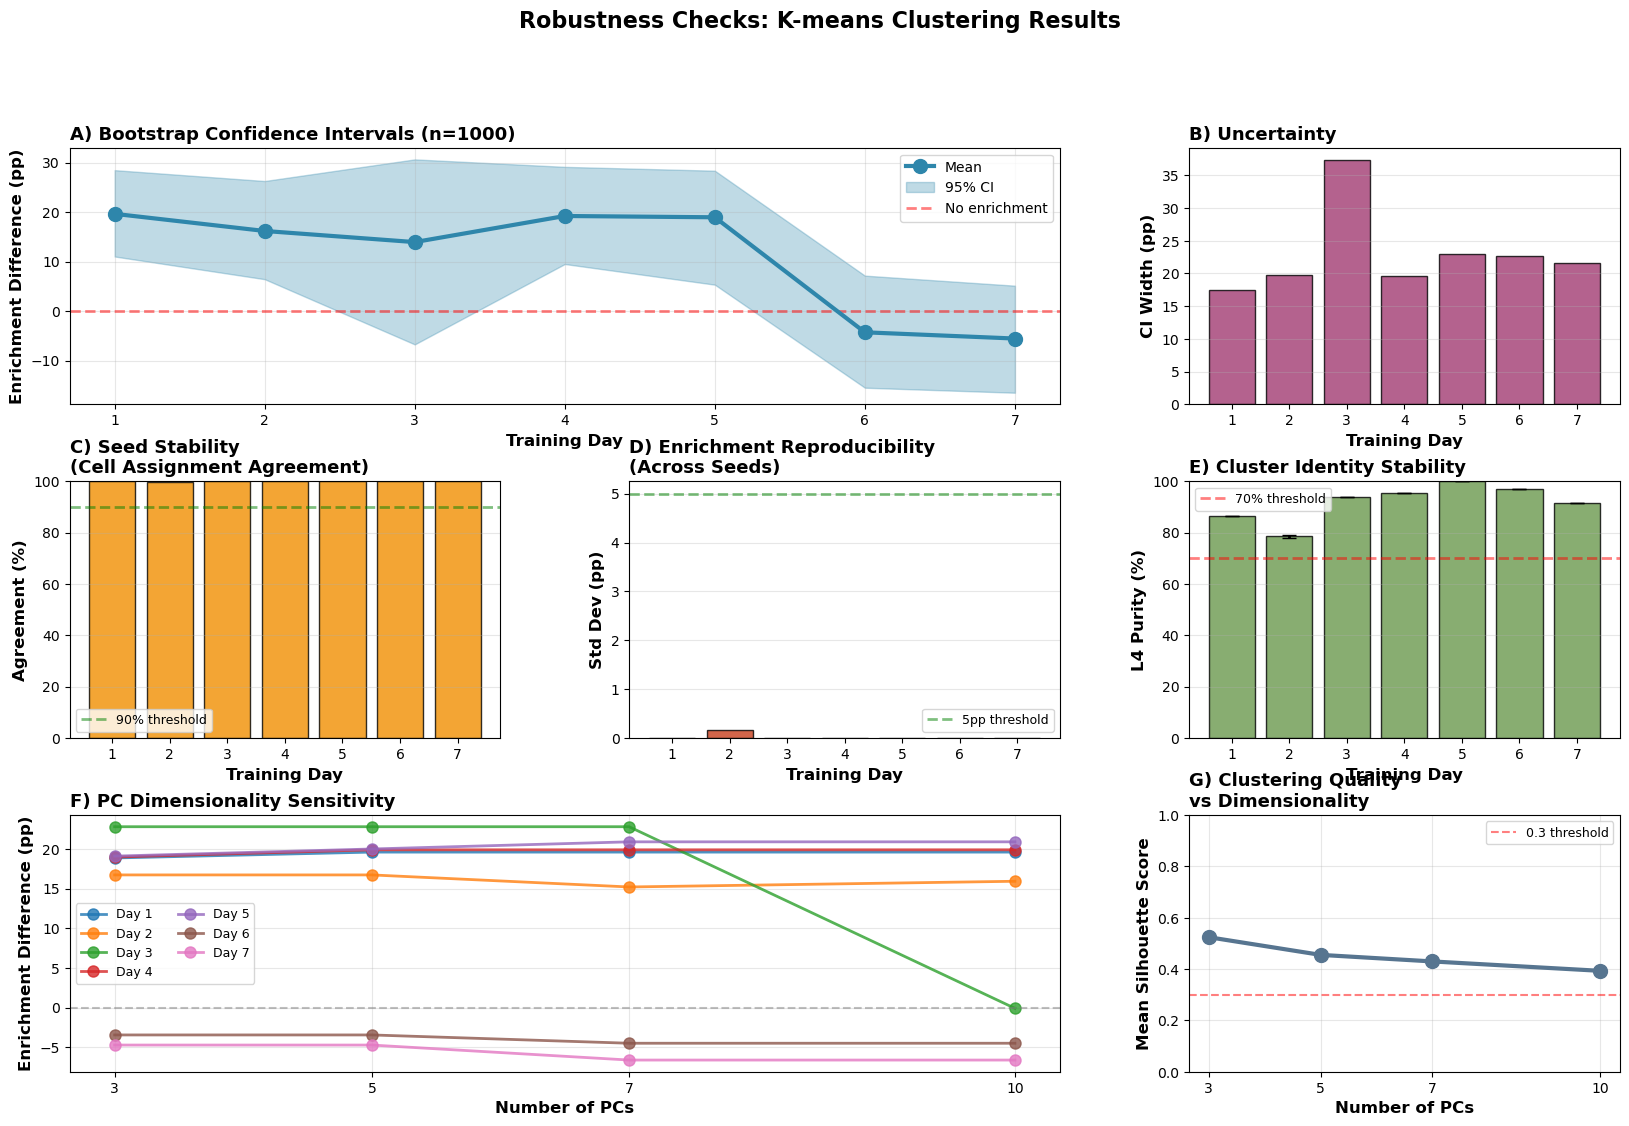

In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================

PCA_DATA_PATH = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\JSY054_pca_data.h5"
FIGURE_DIR = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\figures_robustness"

OPTIMAL_K = 2
BASE_RANDOM_STATE = 42
BASE_N_PCS = 5

# Robustness parameters
N_BOOTSTRAP = 1000
N_SEEDS = 20
PC_RANGE = [3, 5, 7, 10]
RANDOM_SEEDS = [42 + i for i in range(N_SEEDS)]


data = load_data(PCA_DATA_PATH)
session_list = data['session_order']

# Run all robustness checks
bootstrap_results = run_bootstrap_analysis(
    data, session_list, 
    n_pcs=BASE_N_PCS, k=OPTIMAL_K, n_bootstrap=N_BOOTSTRAP
)

seed_results = run_seed_stability_analysis(
    data, session_list,
    n_pcs=BASE_N_PCS, k=OPTIMAL_K, seeds=RANDOM_SEEDS
)

pc_results = run_pc_sensitivity_analysis(
    data, session_list,
    pc_range=PC_RANGE, k=OPTIMAL_K
)

# Create summary
summary_df = create_robustness_summary(
    bootstrap_results, seed_results, pc_results, session_list
)

# Create output directory
os.makedirs(FIGURE_DIR, exist_ok=True)

# Save summary
csv_path = os.path.join(FIGURE_DIR, 'robustness_summary.csv')
summary_df.to_csv(csv_path, index=False)
print(f"\n✓ Saved summary: {csv_path}")

# Generate plot
fig = plot_robustness_results(
    bootstrap_results, seed_results, pc_results, session_list,
    save_path=os.path.join(FIGURE_DIR, 'robustness_checks.png')
)

plt.show()

**Saving aligned activities to .mat file**

In [7]:
"""
Extract_Aligned_Spatial_Activity.py
Extract pre-aligned spatial activity profiles organized by session and layer.

The alignment has already been done and is stored in:
'features/spatial_profiles_aligned'

JSY, 01/2026
"""

import sys
sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")

import os
import numpy as np
import h5py
from scipy.io import savemat
import pickle


# ============================================================================
# CONFIGURATION
# ============================================================================

PCA_DATA_PATH = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\JSY054_pca_data.h5"
OUTPUT_DIR = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\aligned_spatial_matrices"

# Which version to extract
USE_ZSCORE = False  # Set to True if you want z-scored version

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================================
# LOAD DATA
# ============================================================================

def load_data(filepath, use_zscore=False):
    """Load aligned spatial activity and metadata."""
    print(f"Loading data from: {filepath}")
    
    data = {}
    
    with h5py.File(filepath, 'r') as f:
        # Cell metadata
        data['layer_labels'] = f['cells/layer_labels'][:].astype(str)
        data['session_labels'] = f['cells/session_labels'][:].astype(str)
        data['preferred_landmark'] = f['cells/preferred_landmark'][:]
        data['peak_positions'] = f['cells/peak_positions'][:]
        data['cell_depths'] = f['cells/cell_depths'][:]
        
        # Spatial activity - USE PRE-ALIGNED VERSION
        if use_zscore:
            data['spatial_profiles'] = f['features/spatial_profiles_zscore'][:]
            print("  Using z-scored aligned profiles")
        else:
            data['spatial_profiles'] = f['features/spatial_profiles_aligned'][:]
            print("  Using raw aligned profiles")
        
        # Also load original (non-aligned) for comparison if needed
        data['spatial_profiles_original'] = f['features/spatial_profiles'][:]
        
        # Get alignment template for position reference
        if 'alignment/template' in f:
            data['template'] = f['alignment/template'][:]
            n_bins = len(data['template'])
            # Create relative position vector (centered at 0 = landmark)
            data['relative_positions'] = np.linspace(-n_bins/2, n_bins/2, n_bins)
        else:
            n_bins = data['spatial_profiles'].shape[1]
            data['relative_positions'] = np.arange(n_bins) - n_bins//2
        
        # Session order
        unique_sessions = np.unique(data['session_labels'])
        data['session_order'] = sorted(unique_sessions, key=lambda x: int(x.replace('Day', '')))
    
    print(f"  Total cells: {len(data['spatial_profiles'])}")
    print(f"  Spatial bins: {data['spatial_profiles'].shape[1]}")
    print(f"  Sessions: {data['session_order']}")
    print(f"  Layers: {np.unique(data['layer_labels'])}")
    
    return data


# ============================================================================
# ORGANIZE BY SESSION AND LAYER
# ============================================================================

def organize_by_session_layer(data):
    """
    Organize aligned spatial profiles into nested structure:
    organized[session][layer] = {
        'aligned_traces': (n_cells x n_bins),
        'original_traces': (n_cells x n_bins),
        'cell_indices': array of original cell indices,
        'preferred_landmarks': array of preferred landmarks,
        'peak_positions': peak position for each cell,
        'cell_depths': cortical depth for each cell,
        'n_cells': count
    }
    """
    print("\nOrganizing by session and layer...")
    
    spatial_profiles = data['spatial_profiles']  # Already aligned
    spatial_profiles_original = data['spatial_profiles_original']
    layer_labels = data['layer_labels']
    session_labels = data['session_labels']
    preferred_landmark = data['preferred_landmark']
    peak_positions = data['peak_positions']
    cell_depths = data['cell_depths']
    session_order = data['session_order']
    
    organized = {}
    layers = ['L2/3', 'L4', 'L5', 'L6']
    
    for session in session_order:
        organized[session] = {}
        
        for layer in layers:
            # Find cells matching session and layer
            mask = (session_labels == session) & (layer_labels == layer)
            indices = np.where(mask)[0]
            
            if len(indices) == 0:
                organized[session][layer] = {
                    'aligned_traces': np.array([]),
                    'original_traces': np.array([]),
                    'cell_indices': np.array([]),
                    'preferred_landmarks': np.array([]),
                    'peak_positions': np.array([]),
                    'cell_depths': np.array([]),
                    'n_cells': 0
                }
                continue
            
            organized[session][layer] = {
                'aligned_traces': spatial_profiles[indices],
                'original_traces': spatial_profiles_original[indices],
                'cell_indices': indices,
                'preferred_landmarks': preferred_landmark[indices],
                'peak_positions': peak_positions[indices],
                'cell_depths': cell_depths[indices],
                'n_cells': len(indices)
            }
            
            print(f"  {session} {layer}: {len(indices)} cells")
    
    return organized


# ============================================================================
# ORGANIZE BY LANDMARK PREFERENCE
# ============================================================================

def organize_by_landmark(data):
    """
    Alternative organization: by landmark preference instead of layer.
    
    organized_lm[session][landmark] = {
        'aligned_traces': (n_cells x n_bins),
        'layer_labels': array of layer labels,
        'cell_indices': array,
        'n_cells': count
    }
    """
    print("\nOrganizing by landmark preference...")
    
    spatial_profiles = data['spatial_profiles']
    layer_labels = data['layer_labels']
    session_labels = data['session_labels']
    preferred_landmark = data['preferred_landmark']
    session_order = data['session_order']
    
    organized_lm = {}
    landmarks = {0: 'L1', 1: 'L2', 2: 'L3', 3: 'L4'}
    
    for session in session_order:
        organized_lm[session] = {}
        
        for lm_idx, lm_name in landmarks.items():
            mask = (session_labels == session) & (preferred_landmark == lm_idx)
            indices = np.where(mask)[0]
            
            if len(indices) == 0:
                organized_lm[session][lm_name] = {
                    'aligned_traces': np.array([]),
                    'layer_labels': np.array([]),
                    'cell_indices': np.array([]),
                    'n_cells': 0
                }
                continue
            
            organized_lm[session][lm_name] = {
                'aligned_traces': spatial_profiles[indices],
                'layer_labels': layer_labels[indices],
                'cell_indices': indices,
                'n_cells': len(indices)
            }
            
            print(f"  {session} {lm_name}-preferring: {len(indices)} cells")
    
    return organized_lm


# ============================================================================
# SAVE OUTPUTS
# ============================================================================

def save_as_matlab(organized, relative_positions, session_order, filepath, 
                   organized_lm=None):
    """
    Save as MATLAB .mat file.
    
    Structure in MATLAB:
    data.by_layer.Day1.L2_3.aligned_traces (n_cells x n_bins)
    data.by_layer.Day1.L2_3.original_traces
    data.by_layer.Day1.L2_3.cell_indices
    data.by_layer.Day1.L2_3.preferred_landmarks
    data.by_layer.Day1.L2_3.n_cells
    
    data.by_landmark.Day1.L4.aligned_traces (n_cells x n_bins)
    data.by_landmark.Day1.L4.layer_labels
    
    data.relative_positions (n_bins,)  % 0 = landmark center
    data.sessions (cell array)
    """
    print(f"\nSaving MATLAB .mat file...")
    
    matlab_struct = {}
    
    # ========== BY LAYER ==========
    by_layer = {}
    for session in session_order:
        session_data = {}
        
        for layer, layer_data in organized[session].items():
            layer_clean = layer.replace('/', '_')  # L2/3 -> L2_3
            
            session_data[layer_clean] = {
                'aligned_traces': layer_data['aligned_traces'],
                'original_traces': layer_data['original_traces'],
                'cell_indices': layer_data['cell_indices'],
                'preferred_landmarks': layer_data['preferred_landmarks'],
                'peak_positions': layer_data['peak_positions'],
                'cell_depths': layer_data['cell_depths'],
                'n_cells': layer_data['n_cells']
            }
        
        by_layer[session] = session_data
    
    matlab_struct['by_layer'] = by_layer
    
    # # ========== BY LANDMARK ==========
    # if organized_lm is not None:
    #     by_landmark = {}
    #     for session in session_order:
    #         session_data = {}
            
    #         for lm, lm_data in organized_lm[session].items():
    #             session_data[lm] = {
    #                 'aligned_traces': lm_data['aligned_traces'],
    #                 'layer_labels': lm_data['layer_labels'].astype('U'),  # Convert to unicode
    #                 'cell_indices': lm_data['cell_indices'],
    #                 'n_cells': lm_data['n_cells']
    #             }
            
    #         by_landmark[session] = session_data
        
    #     matlab_struct['by_landmark'] = by_landmark
    
    # ========== METADATA ==========
    matlab_struct['relative_positions'] = relative_positions
    matlab_struct['sessions'] = session_order
    matlab_struct['layers'] = ['L2_3', 'L4', 'L5', 'L6']
    # matlab_struct['landmarks'] = ['L1', 'L2', 'L3', 'L4']
    
    # Save
    savemat(filepath, {'data': matlab_struct}, oned_as='column')
    print(f"  ✓ Saved: {filepath}")
    
    # Print usage
    print(f"\n  MATLAB usage examples:")
    print(f"    >> load('{os.path.basename(filepath)}')")
    print(f"    >> traces = data.by_layer.Day1.L5.aligned_traces;  %% All L5 cells Day1")
    print(f"    >> traces = data.by_landmark.Day1.L4.aligned_traces;  %% All L4-pref cells Day1")
    print(f"    >> positions = data.relative_positions;  %% 0 = landmark center")


def save_as_hdf5(organized, relative_positions, session_order, filepath,
                 organized_lm=None):
    """Save as HDF5 (Python & MATLAB compatible)."""
    print(f"\nSaving HDF5 file...")
    
    with h5py.File(filepath, 'w') as f:
        # Metadata
        f.create_dataset('relative_positions', data=relative_positions)
        f.create_dataset('sessions', data=np.array(session_order, dtype='S'))
        
        # ========== BY LAYER ==========
        by_layer_group = f.create_group('by_layer')
        
        for session in session_order:
            session_group = by_layer_group.create_group(session)
            
            for layer, layer_data in organized[session].items():
                layer_clean = layer.replace('/', '_')
                layer_group = session_group.create_group(layer_clean)
                
                layer_group.create_dataset('aligned_traces', data=layer_data['aligned_traces'])
                layer_group.create_dataset('original_traces', data=layer_data['original_traces'])
                layer_group.create_dataset('cell_indices', data=layer_data['cell_indices'])
                layer_group.create_dataset('preferred_landmarks', data=layer_data['preferred_landmarks'])
                layer_group.create_dataset('peak_positions', data=layer_data['peak_positions'])
                layer_group.create_dataset('cell_depths', data=layer_data['cell_depths'])
                layer_group.attrs['n_cells'] = layer_data['n_cells']
        
        # ========== BY LANDMARK ==========
        if organized_lm is not None:
            by_lm_group = f.create_group('by_landmark')
            
            for session in session_order:
                session_group = by_lm_group.create_group(session)
                
                for lm, lm_data in organized_lm[session].items():
                    lm_group = session_group.create_group(lm)
                    
                    lm_group.create_dataset('aligned_traces', data=lm_data['aligned_traces'])
                    lm_group.create_dataset('layer_labels', 
                                           data=lm_data['layer_labels'].astype('S'))
                    lm_group.create_dataset('cell_indices', data=lm_data['cell_indices'])
                    lm_group.attrs['n_cells'] = lm_data['n_cells']
    
    print(f"  ✓ Saved: {filepath}")
    
    print(f"\n  Python usage:")
    print(f"    >> with h5py.File('{os.path.basename(filepath)}', 'r') as f:")
    print(f"    >>     traces = f['by_layer/Day1/L5/aligned_traces'][:]")
    print(f"\n  MATLAB usage:")
    print(f"    >> traces = h5read('{os.path.basename(filepath)}', '/by_layer/Day1/L5/aligned_traces');")


def save_as_pickle(organized, relative_positions, session_order, filepath,
                   organized_lm=None):
    """Save as Python pickle."""
    print(f"\nSaving Python pickle...")
    
    output = {
        'by_layer': organized,
        'by_landmark': organized_lm,
        'relative_positions': relative_positions,
        'session_order': session_order
    }
    
    with open(filepath, 'wb') as f:
        pickle.dump(output, f)
    
    print(f"  ✓ Saved: {filepath}")


# ============================================================================
# SUMMARY
# ============================================================================

def print_summary(organized, organized_lm, session_order):
    """Print summary statistics."""
    print("\n" + "="*80)
    print("SUMMARY: ORGANIZED BY LAYER")
    print("="*80)
    
    for session in session_order:
        print(f"\n{session}:")
        for layer in ['L2/3', 'L4', 'L5', 'L6']:
            n = organized[session][layer]['n_cells']
            print(f"  {layer}: {n:4d} cells")
    
    if organized_lm is not None:
        print("\n" + "="*80)
        print("SUMMARY: ORGANIZED BY LANDMARK PREFERENCE")
        print("="*80)
        
        for session in session_order:
            print(f"\n{session}:")
            for lm in ['L1', 'L2', 'L3', 'L4']:
                n = organized_lm[session][lm]['n_cells']
                print(f"  {lm}-preferring: {n:4d} cells")
    
    print("="*80)


# ============================================================================
# MAIN
# ============================================================================

def main():
    """Main execution."""
    
    # Load data
    data = load_data(PCA_DATA_PATH, use_zscore=USE_ZSCORE)
    
    # Organize by layer
    organized = organize_by_session_layer(data)
    
    # Also organize by landmark preference
    organized_lm = organize_by_landmark(data)
    
    # Print summary
    print_summary(organized, organized_lm, data['session_order'])
    
    # Save in multiple formats
    suffix = '_zscore' if USE_ZSCORE else ''
    base_name = f'JSY054_aligned_spatial_activity{suffix}'
    
    save_as_matlab(
        organized,
        data['relative_positions'],
        data['session_order'],
        os.path.join(OUTPUT_DIR, f'{base_name}.mat')
        # organized_lm=organized_lm
    )
    
    save_as_hdf5(
        organized,
        data['relative_positions'],
        data['session_order'],
        os.path.join(OUTPUT_DIR, f'{base_name}.h5'),
        organized_lm=organized_lm
    )
    
    save_as_pickle(
        organized,
        data['relative_positions'],
        data['session_order'],
        os.path.join(OUTPUT_DIR, f'{base_name}.pkl'),
        organized_lm=organized_lm
    )
    
    print("\n✓ All files saved successfully!")
    print(f"\nOutput directory: {OUTPUT_DIR}")
    
    return organized, organized_lm, data




In [8]:
organized, organized_lm, data = main()

Loading data from: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\JSY054_pca_data.h5
  Using raw aligned profiles
  Total cells: 2864
  Spatial bins: 115
  Sessions: ['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
  Layers: ['L2/3' 'L4' 'L5' 'L6']

Organizing by session and layer...
  Day1 L2/3: 138 cells
  Day1 L4: 138 cells
  Day1 L5: 83 cells
  Day1 L6: 52 cells
  Day2 L2/3: 144 cells
  Day2 L4: 169 cells
  Day2 L5: 98 cells
  Day2 L6: 41 cells
  Day3 L2/3: 178 cells
  Day3 L4: 163 cells
  Day3 L5: 102 cells
  Day3 L6: 38 cells
  Day4 L2/3: 180 cells
  Day4 L4: 165 cells
  Day4 L5: 95 cells
  Day4 L6: 14 cells
  Day5 L2/3: 124 cells
  Day5 L4: 146 cells
  Day5 L5: 81 cells
  Day5 L6: 30 cells
  Day6 L2/3: 95 cells
  Day6 L4: 96 cells
  Day6 L5: 83 cells
  Day6 L6: 51 cells
  Day7 L2/3: 123 cells
  Day7 L4: 108 cells
  Day7 L5: 78 cells
  Day7 L6: 51 cells

Organizing by landmark preference...
  Day1 L1-preferring: 294 cells
  Day1 L2-preferring: 10 cells
  Da